In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import ticker
from scipy.stats import lognorm, norm
from pypesto.store import read_from_hdf5
from pypesto import profile
from scipy.stats import t as t_dist
import scipy
import seaborn as sns

In [2]:
from inference.helper_functions import compute_error_estimate, transform_pesto_results
from inference.nlme_objective import ObjectiveFunctionNLME

/Users/jonas.arruda/miniconda/envs/AmortizedNLMEs/lib/python3.9/site-packages/bayesflow/trainers.py:26: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
import matplotlib
matplotlib.rcdefaults()  # for resetting to defaults

In [4]:
plt.rcParams.update({'font.size': 25,
                     'text.usetex': True,
                     "font.family": "serif",
                     "font.serif": ["Computer Modern Roman"],
                     'axes.titlesize': 'small',
                     'axes.labelsize': 'small',
                     'xtick.labelsize': 'small',
                     'ytick.labelsize': 'small',
                     'legend.fontsize': 'small',
                     #'figure.dpi': 600,
                     'figure.figsize': (16,12)}) #
colors = ['#1f78b4', '#a6cee3', '#b2df8a','#33a02c','#fb9a99']
# colors = ["#586ba4", "#324376", "#B7990D", "#f68e5f", "#f76c5e"]  # SDE before: "#f5dd90"
#['#d7191c', '#fdae61', '#ffffbf', '#abd9e9', '#2c7bb6']

plt.style.use(['science']) #'nature'])
#plt.style.use('ggplot')
plt.rcParams.update({#'text.usetex' : True,
                     'font.size': 25,
                     #'font.family' : 'serif',
                     #'mathtext.fontset':  ,
                     'axes.titlesize': 'x-small',
                     'axes.labelsize': 'xx-small',
                     'xtick.labelsize': 'xx-small',
                     'ytick.labelsize': 'xx-small',
                     'legend.fontsize': 'xx-small',
                     #'figure.dpi': 600,
                     'figure.figsize': (16,12)})
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [5]:
# Cell Specific Posterior Samples
# specify which model to use
model_name = ['fröhlich-small', 'fröhlich-large', 'fröhlich-sde', 'pharmacokinetic_model'][0]

## Load the ODE model
if model_name == 'fröhlich-small':
    from models.froehlich_model_small import FroehlichModelSmall
    model = FroehlichModelSmall(load_best=True)

    use_presimulation = False
elif model_name == 'fröhlich-large':
    from models.froehlich_model_large import FroehlichModelLarge
    model = FroehlichModelLarge(load_best=True)

    use_presimulation = True
    presimulation_path = 'data/presimulations_froehlich_large'

elif model_name == 'fröhlich-sde':
    from models.froehlich_model_sde import FroehlichModelSDE
    model = FroehlichModelSDE(load_best=True)

    use_presimulation = True
    presimulation_path = 'data/presimulations_froehlich_sde'

elif model_name == 'pharmacokinetic_model':
    from models.pharmacokinetic_model import PharmacokineticModel
    model = PharmacokineticModel(load_best=True)

    use_presimulation = True
    presimulation_path = 'data/presimulations_pharma'
else:
    raise NotImplementedError('model not implemented')

path_store_network = 'networks/' + model.network_name

# assemble simulator and prior
simulator =  model.build_simulator()
trainer = model.build_trainer(path_store_network)

INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 6)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 180, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


using LSTM with 256 units as summary network
using a 6-layer cINN as inference network
prior mean: [-3 -3  5  0  1 -1]
prior covariance diagonal: [ 5  5 11  2  6  2]
Using the small Froehlich model


INFO:root:Loaded loss history from networks/amortizer-small-fro-6layers-LSTM-500epochs/history_512.pkl.
INFO:root:Loaded simulation memory from networks/amortizer-small-fro-6layers-LSTM-500epochs/memory.pkl
INFO:root:Networks loaded from networks/amortizer-small-fro-6layers-LSTM-500epochs/ckpt-512
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


Model: "amortized_posterior"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 invertible_network (Inverti  multiple                 1204440   
 bleNetwork)                                                     
                                                                 
 lstm (LSTM)                 multiple                  264192    
                                                                 
Total params: 1,468,632
Trainable params: 1,468,560
Non-trainable params: 72
_________________________________________________________________
None


In [6]:
# load synthetic data for specific model # todo: n_data = 1000
obs_data, true_pop_parameters = model.load_data(n_data=500, load_eGFP=False, load_d2eGFP=False)
real_data, _ = model.load_data(n_data=100, load_eGFP=True, load_d2eGFP=True)

if model_name == 'fröhlich-sde':
    cell_param_log = pd.read_csv(f'data/synthetic/synthetic_individual_cell_params_sde_model.csv',
                                 index_col=0, header=0)
elif model_name == 'fröhlich-large':
    cell_param_log = pd.read_csv(f'data/synthetic/synthetic_individual_cell_params_large_model.csv',
                                 index_col=0, header=0)
else:
    cell_param_log = pd.read_csv(f'data/synthetic/synthetic_individual_cell_params.csv',
                                 index_col=0, header=0)
# which data to analyse
#single_cell_id = 100  #100 #5 #3
#data = obs_data[single_cell_id, :][np.newaxis, :]

n_bayesflow_samples = 10000
#param_samples =  model.draw_posterior_samples(data=data, n_samples=n_bayesflow_samples)
#syn_sim = simulator(param_samples)['sim_data']
#syn_median = np.median(syn_sim, axis=0)
#syn_perc = np.percentile(syn_sim.reshape(n_bayesflow_samples, 180), (5, 95), axis=0)

# simulate data from different posterior samples for a real cell
single_real_data, _ = model.load_data(n_data=100, load_eGFP=True, load_d2eGFP=True)
real_single_cell = single_real_data[0][100, :][np.newaxis, :]
param_samples_real =  model.draw_posterior_samples(data=real_single_cell,
                                          n_samples=n_bayesflow_samples)
real_sim = simulator(param_samples_real)['sim_data']
real_median = np.median(real_sim, axis=0)
real_perc = np.percentile(real_sim.reshape(n_bayesflow_samples, 180), (5, 95), axis=0)

real_single_cell2 = single_real_data[0][5, :][np.newaxis, :]
param_samples_real2 =  model.draw_posterior_samples(data=real_single_cell2,
                                          n_samples=n_bayesflow_samples)
real_sim2 = simulator(param_samples_real2)['sim_data']
real_median2 = np.median(real_sim2, axis=0)
real_perc2 = np.percentile(real_sim2.reshape(n_bayesflow_samples, 180), (5, 95), axis=0)

# simulated data
t_points = np.linspace(start=1 / 6, stop=30, num=180, endpoint=True)

In [7]:
# Scalability & Error Analysis
test_n_cells = [50, 100, 200, 500, 1000, 5000, 10000] # 1000
compute_relative_error = False  # relative to true parameter values
epsilon = 1e-4

# read results from monolix
monolix_small_errors = np.zeros(len(test_n_cells))
full_error_list_small = []
n_cells_opt_list_monolix_small = np.array(test_n_cells)[[0,1,2,3,5,6]]
for cell_idx, n_cells in enumerate(test_n_cells):
    if n_cells == 1000: continue  # TODO: missing Clemens
    results_monolix = pd.read_csv(f'output/results_monolix/small_model/estimated_parameters_synthetic_{n_cells}_cells.csv',
                                 index_col=0, header=0)
    true_sample_parameters = pd.read_csv(f'data/synthetic/sample_pop_parameters.csv',
                                      index_col=0, header=0).loc[f'{n_cells}'].values

    results_to_compare = []
    for col in results_monolix.columns:
        temp_res = results_monolix[col].values[[0,1,2,3,4,10,5,6,7,8,9]]
        temp_res[5] = np.log(temp_res[5])
        temp_res = np.concatenate((temp_res, [0]))
        results_to_compare.append(temp_res)
    error_mono = compute_error_estimate(results_to_compare, true_sample_parameters, small_model=True,
                                        relative_error=compute_relative_error)
    full_error_list_small.append(np.array(results_to_compare)-true_sample_parameters)
    error_mono.sort()
    monolix_small_errors[cell_idx] = np.min(error_mono[:10])

monolix_large_errors = np.zeros(len(test_n_cells))
full_error_list_large = []
n_cells_opt_list_monolix_large = [50, 100, 500, 5000, 10000]
for cell_idx, n_cells in enumerate(test_n_cells):
    if n_cells == 1000: continue  # TODO: missing Clemens
    if n_cells == 200: continue  # TODO: missing Clemens
    results_monolix = pd.read_csv(f'output/results_monolix/large_model/synthetic_{n_cells}_poppars.csv',
                                 index_col=0, header=0)
    true_sample_parameters = pd.read_csv(f'data/synthetic/sample_pop_parameters_large_model.csv',
                                      index_col=0, header=0).loc[f'{n_cells}'].values
    results_to_compare = []
    for col in results_monolix.columns:
        temp_res = results_monolix[col].values[[0,1,2,3,4,5,6,7,8,9,20,10,11,12,13,14,15,16,17,18,19]]
        temp_res[10] = np.log(temp_res[10])
        temp_res = np.concatenate((temp_res, [0]))
        results_to_compare.append(temp_res)
    error_mono = compute_error_estimate(np.array(results_to_compare), true_sample_parameters,
                                        relative_error=compute_relative_error, epsilon=epsilon)
    full_error_list_large.append(np.array(results_to_compare)-true_sample_parameters)
    error_mono.sort()
    monolix_large_errors[cell_idx] = np.min(error_mono[:10])

time_monolix_small = pd.read_csv(f'output/results_monolix/small_model/average_optimal_timings.csv', index_col=1, header=0)['average_time'] # already in hours
time_monolix_large = np.zeros(len(n_cells_opt_list_monolix_large))
for cell_idx, n_cells in enumerate(n_cells_opt_list_monolix_large):
    best_runs = pd.read_csv(f'output/results_monolix/large_model/synthetic_{n_cells}_complete_likelihoods.csv', index_col=0, header=0)['run'].values[:10]
    time_monolix_large_full = pd.read_csv(f'output/results_monolix/large_model/synthetic_{n_cells}_timings.csv', header=0)
    for run in time_monolix_large_full.values:
        if run[-1] in best_runs:
            time_monolix_large[cell_idx] += run[0]
    # sort by ll
    time_monolix_large[cell_idx] = time_monolix_large[cell_idx] / best_runs.size
time_monolix_large = time_monolix_large / 60 / 60  # in hours

In [8]:
#print(model.param_names)
#plt.boxplot(np.concatenate(full_error_list_small, axis=0))
#plt.show()
#print(model_large.param_names)
#plt.boxplot(np.concatenate(full_error_list_large, axis=0))
#plt.show()

In [9]:
# own method
n_samples_opt_list = [10, 50, 100]

rel_error_small = np.zeros((len(test_n_cells), len(n_samples_opt_list)))
time_opt_small = np.zeros((len(test_n_cells), len(n_samples_opt_list)))
for i, n_cells in enumerate(test_n_cells):
    true_sample_parameters = pd.read_csv(f'data/synthetic/sample_pop_parameters.csv',
                                      index_col=0, header=0).loc[f'{n_cells}'].values
    for j, sample_size in enumerate(n_samples_opt_list):
        result = read_from_hdf5.read_result(f'output/scalability/FroehlichModelSmall_cells_{n_cells}_samples_{sample_size}.hd5')
        best_params_list = result.optimize_result.as_dataframe()['x']
        best_params_list_array = np.zeros((len(best_params_list), 12))
        for l in range(len(best_params_list)):
            best_params_list_array[l] = np.concatenate((best_params_list[l][:6], np.exp(-best_params_list[l][6:])))
        error = compute_error_estimate(best_params_list_array, true_sample_parameters,
                                       relative_error=compute_relative_error, epsilon=epsilon)
        error.sort()
        rel_error_small[i,j] = np.median(error[:10])
        time_list = result.optimize_result.as_dataframe()['time']  # in seconds
        time_opt_small[i,j] = np.mean(time_list) / 60 / 60

rel_error_large = np.zeros((len(test_n_cells), len(n_samples_opt_list)))
time_opt_large = np.zeros((len(test_n_cells), len(n_samples_opt_list)))
for i, n_cells in enumerate(test_n_cells):
    true_sample_parameters = pd.read_csv(f'data/synthetic/sample_pop_parameters_large_model.csv',
                                      index_col=0, header=0).loc[f'{n_cells}'].values
    for j, sample_size in enumerate(n_samples_opt_list):
        result = read_from_hdf5.read_result(f'output/scalability/FroehlichModelLarge_'
                                                f'cells_{n_cells}_samples_{sample_size}.hd5')
        #result = read_from_hdf5.read_result(f'output/scalability/FroehlichModelLarge_cells_{n_cells}_samples_{sample_size}.hd5')
        best_params_list = result.optimize_result.as_dataframe()['x']
        best_params_list_array = np.zeros((len(best_params_list), 22))
        for l in range(len(best_params_list)):
            best_params_list_array[l] = np.concatenate((best_params_list[l][:11], np.exp(-best_params_list[l][11:])))
        error = compute_error_estimate(best_params_list_array, true_sample_parameters,
                                       relative_error=compute_relative_error, epsilon=epsilon)
        error.sort()
        rel_error_large[i,j] = np.median(error[:10])
        time_list = result.optimize_result.as_dataframe()['time']  # in seconds
        time_opt_large[i,j] = np.mean(time_list) / 60 / 60

rel_error_sde = np.zeros((len(test_n_cells), len(n_samples_opt_list)))
time_opt_sde = np.zeros((len(test_n_cells), len(n_samples_opt_list)))
for i, n_cells in enumerate(test_n_cells):
    true_sample_parameters = pd.read_csv(f'data/synthetic/sample_pop_parameters_sde_model.csv',
                                      index_col=0, header=0).loc[f'{n_cells}'].values
    for j, sample_size in enumerate(n_samples_opt_list):
        result = read_from_hdf5.read_result(f'output/scalability/FroehlichModelSDE_cells_{n_cells}_samples_{sample_size}.hd5')
        best_params_list = result.optimize_result.as_dataframe()['x']
        best_params = np.concatenate((best_params_list[0][:8], np.exp(-best_params_list[0][8:])))
        error = compute_error_estimate(best_params[np.newaxis], true_sample_parameters,
                                       relative_error=compute_relative_error, epsilon=epsilon)
        rel_error_sde[i,j] = error
        time_list = result.optimize_result.as_dataframe()['time']  # in seconds
        time_opt_sde[i,j] = np.max(time_list) / 60 / 60

# add training time
time_opt_small += 6.55
time_opt_large += 19.26
time_opt_sde += 18.38

This problem is not to be used without a separately created objective.
INFO:pypesto.store.read_from_hdf5:WARNING: You are loading a problem.
This problem is not to be used without a separately created objective.
Loading the profiling result failed. It is highly likely that no profiling result exists within output/scalability/FroehlichModelSmall_cells_50_samples_10.hd5.
Loading the sampling result failed. It is highly likely that no sampling result exists within output/scalability/FroehlichModelSmall_cells_50_samples_10.hd5.
This problem is not to be used without a separately created objective.
INFO:pypesto.store.read_from_hdf5:WARNING: You are loading a problem.
This problem is not to be used without a separately created objective.
Loading the profiling result failed. It is highly likely that no profiling result exists within output/scalability/FroehlichModelSmall_cells_50_samples_50.hd5.
Loading the sampling result failed. It is highly likely that no sampling result exists within outp

In [10]:
from models.froehlich_model_small import FroehlichModelSmall
model_small = FroehlichModelSmall(load_best=True)
path_store_network = 'networks/' + model_small.network_name
simulator_small = model_small.build_simulator()
_ = model_small.build_trainer(path_store_network)

from models.froehlich_model_large import FroehlichModelLarge
model_large = FroehlichModelLarge(load_best=True)
path_store_network = 'networks/' + model_large.network_name
simulator_large = model_large.build_simulator()
_ = model_large.build_trainer(path_store_network)

from models.froehlich_model_sde import FroehlichModelSDE
model_sde = FroehlichModelSDE(load_best=True)
path_store_network = 'networks/' + model_sde.network_name
simulator_sde = model_sde.build_simulator()
_ = model_sde.build_trainer(path_store_network)

obj_fun_amortized = ObjectiveFunctionNLME(model_name=model_small.name,
                                          param_samples=np.empty((1,1,1)),
                                          prior_mean=model.prior_mean,
                                          prior_std=model.prior_std,
                                          covariance_format='diag',
                                          # np.exp(-3.41) * 1.5  # 1.5 times the median of the posterior standard deviations
                                          penalize_correlations=None,
                                          huber_loss_delta=None)
obj_fun_amortized_large = ObjectiveFunctionNLME(model_name=model_large.name,
                                          param_samples=np.empty((1,1,1)),
                                          prior_mean=model_large.prior_mean,
                                          prior_std=model_large.prior_std,
                                          covariance_format='diag',
                                          # np.exp(-3.41) * 1.5  # 1.5 times the median of the posterior standard deviations
                                          penalize_correlations=None,
                                          huber_loss_delta=None)
obj_fun_amortized_sde = ObjectiveFunctionNLME(model_name=model_sde.name,
                                          param_samples=np.empty((1,1,1)),
                                          prior_mean=model_sde.prior_mean,
                                          prior_std=model_sde.prior_std,
                                          covariance_format='diag',
                                          # np.exp(-3.41) * 1.5  # 1.5 times the median of the posterior standard deviations
                                          penalize_correlations=None,
                                          huber_loss_delta=None)

result_small = read_from_hdf5.read_result('output/multi-experiment/fröhlich-small_diag_0') # _test_full.hd5
param_idx_egfp = [i_n for i_n, name in enumerate(result_small.problem.x_names) if 'd2eGFP' not in name]
result_small = result_small.optimize_result.as_dataframe()['x'][0][param_idx_egfp]
estimated_beta = result_small[:6]
estimated_psi = obj_fun_amortized.get_covariance(result_small[6:])

result_large = read_from_hdf5.read_result('output/multi-experiment/fröhlich-large_diag_0')
param_idx_egfp = [i_n for i_n, name in enumerate(result_large.problem.x_names) if 'd2eGFP' not in name]
result_large = result_large.optimize_result.as_dataframe()['x'][0][param_idx_egfp]
estimated_beta_large = result_large[:11]
estimated_psi_large = obj_fun_amortized_large.get_covariance(result_large[11:])

result_sde = read_from_hdf5.read_result('output/multi-experiment/fröhlich-sde_diag_0')
#result_sde = read_from_hdf5.read_result('output/multi-experiment/fröhlich-sde_diag_0.hd5')
param_idx_egfp = [i_n for i_n, name in enumerate(result_sde.problem.x_names) if 'd2eGFP' not in name]
result_sde = result_sde.optimize_result.as_dataframe()['x'][0][param_idx_egfp]
estimated_beta_sde = result_sde[:8]
estimated_psi_sde = obj_fun_amortized_sde.get_covariance(result_sde[8:])

mat_small = scipy.io.loadmat('data/froehlich_eGFP/code/S=[5,6]_transfection_norm.mat')
param_estimates_small = mat_small['parameters_MEM'][0,0][6][0][0][4]
likelihood_small = mat_small['parameters_MEM'][0,0][6][0][0][2]
best_id_small = np.nanargmax(likelihood_small)
estimated_beta_fro = param_estimates_small[:6, best_id_small][[0,1,3,4,5,5]]
var_small = np.exp(param_estimates_small[6:, best_id_small])[[0,1,3,4,5,5]]
estimated_psi_fro = np.diag(var_small)

np.random.seed(42)
# sample from log normal distribution
n_trajectories = len(real_data[0])
reproduced_param = np.random.multivariate_normal(estimated_beta,
                                                     estimated_psi,
                                                     size=n_trajectories*10)
reproduced_param_large = np.random.multivariate_normal(estimated_beta_large,
                                                        estimated_psi_large,
                                                        size=n_trajectories*10)
reproduced_param_sde = np.random.multivariate_normal(estimated_beta_sde,
                                                        estimated_psi_sde,
                                                        size=n_trajectories*10)
reproduced_param_fro = np.random.multivariate_normal(estimated_beta_fro,
                                                        estimated_psi_fro,
                                                        size=n_trajectories*10)

reproduced_data = simulator_small(reproduced_param)['sim_data']
reproduced_data_large = simulator_large(reproduced_param_large)['sim_data']
reproduced_data_sde = simulator_sde(reproduced_param_sde)['sim_data']

simulator_small_without_noise = model_small.build_simulator(with_noise=False)
simulator_large_without_noise = model_large.build_simulator(with_noise=False)
simulator_sde_without_noise = model_sde.build_simulator(with_noise=False)
median_sim_small = simulator_small_without_noise(estimated_beta[np.newaxis])['sim_data']
median_sim_large = simulator_large_without_noise(estimated_beta_large[np.newaxis])['sim_data']
median_sim_sde = simulator_sde_without_noise(np.repeat(estimated_beta_sde[np.newaxis], 100, axis=0))['sim_data']

simulator_fro = model_small.build_simulator(with_noise=False, exp_func='power10')
reproduced_data_fro = simulator_fro(reproduced_param_fro)['sim_data']

real_mean = np.mean(real_data[0], axis=0)

small_mean = np.mean(reproduced_data, axis=0)
dif = small_mean - real_mean
std = np.std(reproduced_data, axis=0)
large_mean = np.mean(reproduced_data_large, axis=0)
dif_large = large_mean - real_mean
std_large = np.std(reproduced_data_large, axis=0)
sde_mean = np.mean(reproduced_data_sde, axis=0)
dif_sde = sde_mean - real_mean
std_sde = np.std(reproduced_data_sde, axis=0)
dif_fro = np.mean(reproduced_data_fro, axis=0) - real_mean
std_fro = np.std(reproduced_data_fro, axis=0)

t_value_05 = abs(t_dist.ppf(0.05 / reproduced_data.shape[1], df=reproduced_data.shape[0] - 1))

confidence_band_upper_05 = dif + t_value_05 * std / np.sqrt(reproduced_data.shape[0])
confidence_band_lower_05 = dif - t_value_05 * std / np.sqrt(reproduced_data.shape[0])
confidence_band_upper_05_large = dif_large + t_value_05 * std_large / np.sqrt(reproduced_data.shape[0])
confidence_band_lower_05_large = dif_large - t_value_05 * std_large / np.sqrt(reproduced_data.shape[0])
confidence_band_upper_05_sde = dif_sde + t_value_05 * std_sde / np.sqrt(reproduced_data.shape[0])
confidence_band_lower_05_sde = dif_sde - t_value_05 * std_sde / np.sqrt(reproduced_data.shape[0])
confidence_band_upper_05_fro = dif_fro + t_value_05 * std_fro / np.sqrt(reproduced_data.shape[0])
confidence_band_lower_05_fro = dif_fro - t_value_05 * std_fro / np.sqrt(reproduced_data.shape[0])

INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 6)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 180, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


using LSTM with 256 units as summary network
using a 6-layer cINN as inference network
prior mean: [-3 -3  5  0  1 -1]
prior covariance diagonal: [ 5  5 11  2  6  2]
Using the small Froehlich model


INFO:root:Loaded loss history from networks/amortizer-small-fro-6layers-LSTM-500epochs/history_512.pkl.
INFO:root:Loaded simulation memory from networks/amortizer-small-fro-6layers-LSTM-500epochs/memory.pkl
INFO:root:Networks loaded from networks/amortizer-small-fro-6layers-LSTM-500epochs/ckpt-512
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


Model: "amortized_posterior_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 invertible_network_1 (Inver  multiple                 1204440   
 tibleNetwork)                                                   
                                                                 
 lstm_1 (LSTM)               multiple                  264192    
                                                                 
Total params: 1,468,632
Trainable params: 1,468,560
Non-trainable params: 72
_________________________________________________________________
None


  Activating project at `~/PyCharm Projects/AmortizedNLME/models/SimulatorFroehlich`


...

INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 11)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 180, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.
INFO:root:Loaded loss history from networks/amortizer-large-fro-9layers-LSTM-1000epochs/history_1001.pkl.
INFO:root:Loaded simulation memory from networks/amortizer-large-fro-9layers-LSTM-1000epochs/memory.pkl
INFO:root:Networks loaded from networks/amortizer-large-fro-9layers-LSTM-1000epochs/ckpt-1001
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


Model: "amortized_posterior_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 invertible_network_2 (Inver  multiple                 1829970   
 tibleNetwork)                                                   
                                                                 
 lstm_2 (LSTM)               multiple                  264192    
                                                                 
Total params: 2,094,162
Trainable params: 2,093,964
Non-trainable params: 198
_________________________________________________________________
None
using 2 layers of MultiConv1D,a LSTM with 256 units and a dense layer with output dimension 20 as summary network
using a 7-layer cINN as inference network
prior mean: [-3 -3 -1  5  0  0  1 -3]
prior covariance diagonal: [5 5 5 5 5 2 5 2]
Using the SDE version of the Froehlich model


INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 8)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 180, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.
INFO:root:Loaded loss history from networks/amortizer-sde-fro-7layers-1000epochs/history_1000.pkl.
INFO:root:Loaded simulation memory from networks/amortizer-sde-fro-7layers-1000epochs/memory.pkl
INFO:root:Networks loaded from networks/amortizer-sde-fro-7layers-1000epochs/ckpt-1000
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


Model: "amortized_posterior_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 invertible_network_3 (Inver  multiple                 566608    
 tibleNetwork)                                                   
                                                                 
 sequential_network (Sequent  multiple                 308532    
 ialNetwork)                                                     
                                                                 
Total params: 875,140
Trainable params: 875,028
Non-trainable params: 112
_________________________________________________________________
None


This problem is not to be used without a separately created objective.
INFO:pypesto.store.read_from_hdf5:WARNING: You are loading a problem.
This problem is not to be used without a separately created objective.
Loading the profiling result failed. It is highly likely that no profiling result exists within output/multi-experiment/fröhlich-small_diag_0.
Loading the sampling result failed. It is highly likely that no sampling result exists within output/multi-experiment/fröhlich-small_diag_0.
This problem is not to be used without a separately created objective.
INFO:pypesto.store.read_from_hdf5:WARNING: You are loading a problem.
This problem is not to be used without a separately created objective.
Loading the profiling result failed. It is highly likely that no profiling result exists within output/multi-experiment/fröhlich-large_diag_0.
Loading the sampling result failed. It is highly likely that no sampling result exists within output/multi-experiment/fröhlich-large_diag_0.
This pro

In [11]:
from models.froehlich_model_large import FroehlichModelLarge
model_large = FroehlichModelLarge(load_best=True)
path_store_network = 'networks/' + model_large.network_name
simulator_large = model_large.build_simulator()
_ = model_large.build_trainer(path_store_network)

obj_fun_amortized = ObjectiveFunctionNLME(model_name=model_small.name,
                                          param_samples=np.empty((1,1,1)),
                                          prior_mean=model.prior_mean,
                                          prior_std=model.prior_std,
                                          covariance_format='diag',
                                          # np.exp(-3.41) * 1.5  # 1.5 times the median of the posterior standard deviations
                                          penalize_correlations=None,
                                          huber_loss_delta=None)
obj_fun_amortized_corr = ObjectiveFunctionNLME(model_name=model_large.name,
                                          param_samples=np.empty((1,1,1)),
                                          prior_mean=model_large.prior_mean,
                                          prior_std=model_large.prior_std,
                                          covariance_format='cholesky',
                                          # np.exp(-3.41) * 1.5  # 1.5 times the median of the posterior standard deviations
                                          penalize_correlations=None,
                                          huber_loss_delta=None)

result_large = read_from_hdf5.read_result('output/real_data/fröhlich-large-diag.h5')
param_idx_egfp = [i_n for i_n, name in enumerate(result_large.problem.x_names) if 'd2eGFP' not in name]
result_large = result_large.optimize_result.as_dataframe()['x'][0][param_idx_egfp]

estimated_beta = result_large[:11]
estimated_psi = obj_fun_amortized.get_covariance(result_large[11:])


result_large_with_corr = read_from_hdf5.read_result('output/real_data/fröhlich-large-corr-0.5.h5')
param_idx_egfp = [i_n for i_n, name in enumerate(result_large_with_corr.problem.x_names) if 'd2eGFP' not in name]
result_large_with_corr = result_large_with_corr.optimize_result.as_dataframe()['x'][0][param_idx_egfp]

estimated_beta_d2 = result_large_with_corr[:11]
estimated_psi_d2 = obj_fun_amortized_corr.get_covariance(result_large_with_corr[11:])

np.random.seed(42)
# sample from log normal distribution
n_trajectories = len(real_data[0])
reproduced_param = np.random.multivariate_normal(estimated_beta,
                                                     estimated_psi,
                                                     size=n_trajectories*10)
reproduced_param_d2 = np.random.multivariate_normal(estimated_beta_d2,
                                                        estimated_psi_d2,
                                                        size=n_trajectories*10)

reproduced_data = simulator_large(reproduced_param)['sim_data']
reproduced_data_d2 = simulator_large(reproduced_param_d2)['sim_data']

real_mean = np.mean(real_data[0], axis=0)
dif_no_corr = np.mean(reproduced_data, axis=0) - real_mean
std = np.std(reproduced_data, axis=0)
dif_corr = np.mean(reproduced_data_d2, axis=0) - real_mean
std2 = np.std(reproduced_data_d2, axis=0)

t_value_05 = abs(t_dist.ppf(0.05 / reproduced_data.shape[1], df=reproduced_data.shape[0] - 1))

confidence_band_upper_no_corr = dif_no_corr + t_value_05 * std / np.sqrt(reproduced_data.shape[0])
confidence_band_lower_no_corr = dif_no_corr - t_value_05 * std / np.sqrt(reproduced_data.shape[0])
confidence_band_upper_corr = dif_corr + t_value_05 * std2 / np.sqrt(reproduced_data.shape[0])
confidence_band_lower_corr = dif_corr - t_value_05 * std2 / np.sqrt(reproduced_data.shape[0])

using LSTM with 256 units as summary network
using a 9-layer cINN as inference network
prior mean: [ 0 -1  0 12  0  1 -3 -6  0  2 -1]
prior covariance diagonal: [5. 5. 2. 1. 2. 2. 2. 5. 2. 6. 2.]
Using the large Froehlich model


INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 11)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 180, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.
INFO:root:Loaded loss history from networks/amortizer-large-fro-9layers-LSTM-1000epochs/history_1001.pkl.
INFO:root:Loaded simulation memory from networks/amortizer-large-fro-9layers-LSTM-1000epochs/memory.pkl
INFO:root:Networks loaded from networks/amortizer-large-fro-9layers-LSTM-1000epochs/ckpt-1001
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


Model: "amortized_posterior_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 invertible_network_4 (Inver  multiple                 1829970   
 tibleNetwork)                                                   
                                                                 
 lstm_4 (LSTM)               multiple                  264192    
                                                                 
Total params: 2,094,162
Trainable params: 2,093,964
Non-trainable params: 198
_________________________________________________________________


This problem is not to be used without a separately created objective.
INFO:pypesto.store.read_from_hdf5:WARNING: You are loading a problem.
This problem is not to be used without a separately created objective.
Loading the profiling result failed. It is highly likely that no profiling result exists within output/real_data/fröhlich-large-diag.h5.
Loading the sampling result failed. It is highly likely that no sampling result exists within output/real_data/fröhlich-large-diag.h5.
This problem is not to be used without a separately created objective.
INFO:pypesto.store.read_from_hdf5:WARNING: You are loading a problem.
This problem is not to be used without a separately created objective.
Loading the profiling result failed. It is highly likely that no profiling result exists within output/real_data/fröhlich-large-corr-0.5.h5.
Loading the sampling result failed. It is highly likely that no sampling result exists within output/real_data/fröhlich-large-corr-0.5.h5.


None


## Result Figure 1

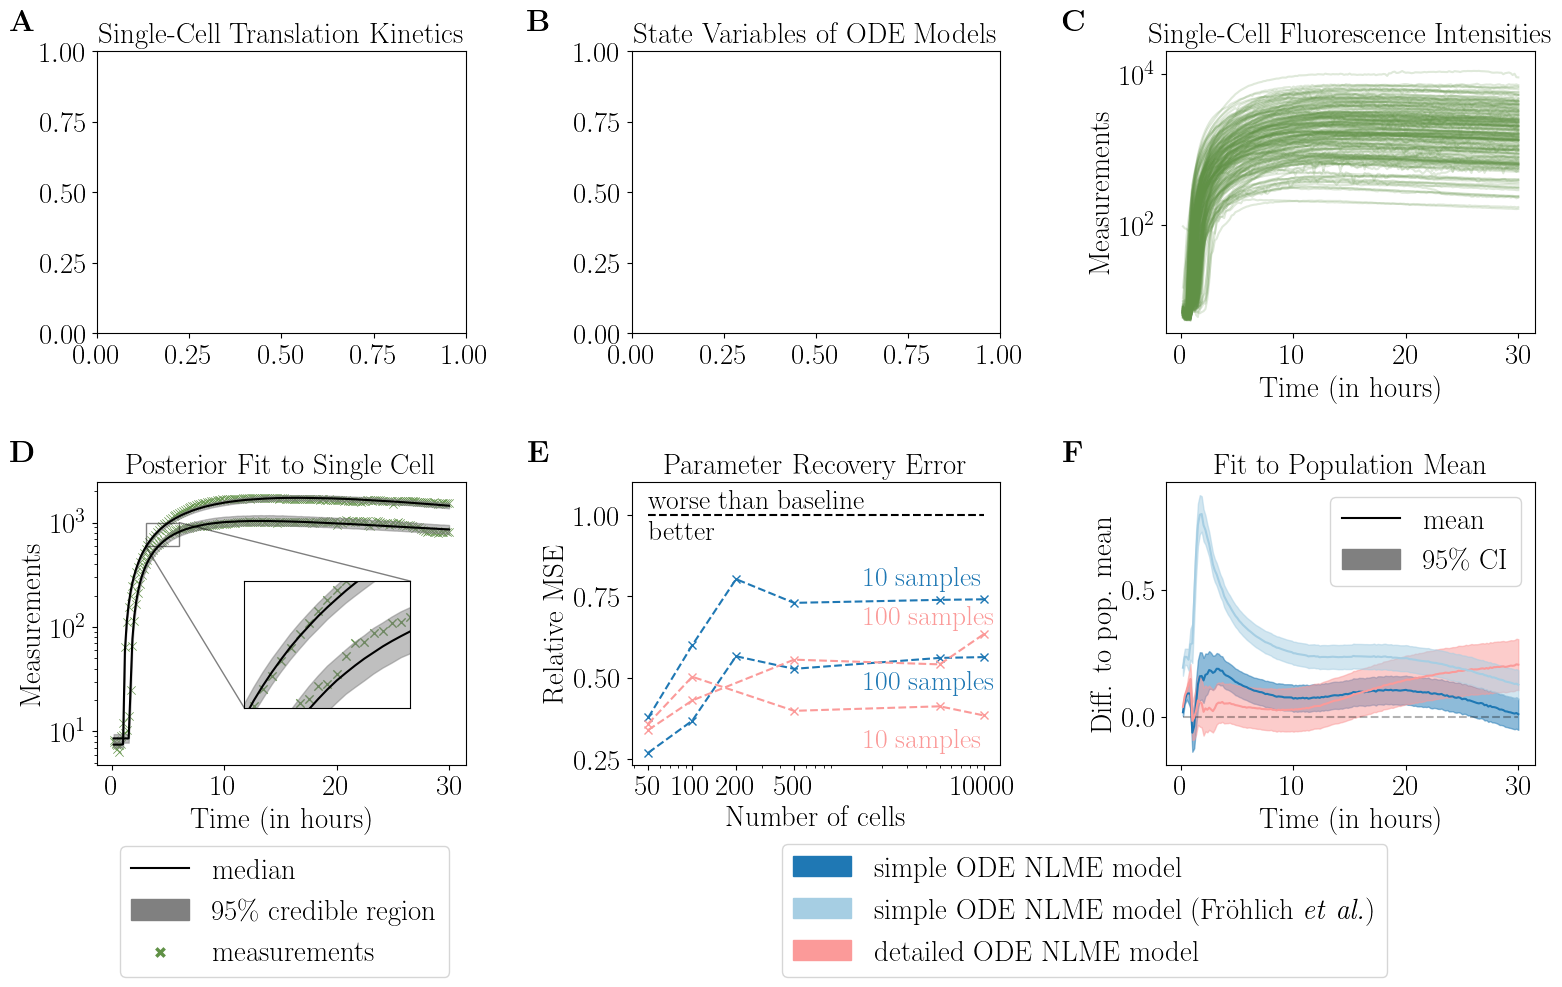

In [15]:
fig_total, ax_total = plt.subplots(nrows=2, ncols=3, figsize=(16, 9),
                                   layout="tight")
#grid = plt.GridSpec(1, 3, figure=fig_total) # height_ratios
ax0, ax1_0, ax1, ax2, ax4, ax3 = ax_total.flatten()
#= fig_total.add_subplot(grid[0, 0])
#ax3 = fig_total.add_subplot(grid[0, 1])##
#ax4 = fig_total.add_subplot(grid[0, 2])

cell_color = '#609146'  # '#3FC834'

##################### Data & Models
ax0.set_title('Single-Cell Translation Kinetics ')
ax1_0.set_title('State Variables of ODE Models')
ax1.set_title('Single-Cell Fluorescence Intensities')
for i, cell in enumerate(real_data[0]):
    if i > 200: break
    ax1.plot(t_points, np.exp(cell.flatten()), color=cell_color, alpha=0.2)
ax1.set_xlabel('Time (in hours)')
ax1.set_ylabel('Measurements')
ax1.set_yscale('log')
ax1.set_xlabel('Time (in hours)')
ax1.set_yscale('log')
ax1.set_ylim(ax1.get_ylim()[0], 2e4)

###################### Posterior Simulation
ax2.scatter(t_points, np.exp(real_single_cell2.flatten()), c=cell_color, marker='x', linewidth=0.5)
ax2.scatter(t_points, np.exp(real_single_cell.flatten()), c=cell_color, marker='x', linewidth=0.5)
ax2.fill_between(t_points, np.exp(real_perc2[0, :]), np.exp(real_perc2[1, :]), color='grey', alpha=0.5, label=f'95\% credible region')
region = ax2.fill_between(t_points, np.exp(real_perc[0, :]), np.exp(real_perc[1, :]), color='grey', alpha=0.5, label=f'95\% credible region')
median, = ax2.plot(t_points, np.exp(real_median), color='black', label=f'posterior median')
ax2.plot(t_points, np.exp(real_median2), color='black')
ax2.set_xlabel('Time (in hours)')
ax2.set_ylabel('Measurements')#'fluorescence intensity [a.u.]')
ax2.set_yscale('log')
ax2.set_title('Posterior Fit to Single Cell')
#syn_patch = ax2.scatter([],[], marker='x',  c=colors[0], linewidth=2.5, label='synthetic cell')  # not visible
real_patch = ax2.scatter([],[], marker='x',  c=cell_color, linewidth=2.5, label='measurements')  # not visible
#ax2.legend(handles=[real_patch, syn_patch, region, median], loc='lower right')
#ax1.legend(loc='lower right')

zax = ax2.inset_axes([0.4, 0.2, 0.45, 0.45])
zax.scatter(t_points, np.exp(real_single_cell2.flatten()), c=cell_color, marker='x', linewidth=1)
zax.scatter(t_points, np.exp(real_single_cell.flatten()), c=cell_color, marker='x', linewidth=1)
zax.fill_between(t_points, np.exp(real_perc2[0, :]), np.exp(real_perc2[1, :]), color='grey', alpha=0.5, label=f'95\% credible region')
zax.fill_between(t_points, np.exp(real_perc[0, :]), np.exp(real_perc[1, :]), color='grey', alpha=0.5, label=f'95\% credible region')
zax.plot(t_points, np.exp(real_median), color='black', label=f'posterior median')
zax.plot(t_points, np.exp(real_median2), color='black')
zax.set_yscale('log')
#zax.set_xlim(5,8)
#zax.set_ylim(5e2,3e3)
zax.set_xlim(3,6)
zax.set_ylim(6e2,1e3)
zax.set_xticks([])
zax.set_yticks([], minor=True)
zax.set_yticks([])
ax2.indicate_inset_zoom(zax, edgecolor="black")

###################### population fit (small, large, fröhlich) compared to Fröhlich
# plot real synthetic data vs estimated data
t_points = np.linspace(start=1 / 6, stop=30, num=real_single_cell.shape[1], endpoint=True)

ax3.fill_between(t_points, confidence_band_upper_05.flatten(), confidence_band_lower_05.flatten(),
                         color=colors[0], alpha=0.5, label='95\% confidence band')
ax3.plot(t_points, dif, color=colors[0], label='estimation difference')
ax3.plot(t_points, np.zeros(t_points.size), color='black', linestyle='--', alpha=0.3)

ax3.fill_between(t_points, confidence_band_upper_05_large.flatten(), confidence_band_lower_05_large.flatten(),
                         color=colors[4], alpha=0.5, label='95\% confidence band')
ax3.plot(t_points, dif_large, color=colors[4], label='estimation difference')

#ax3.fill_between(t_points, confidence_band_upper_05_sde.flatten(), confidence_band_lower_05_sde.flatten(),
#                         color=colors[2], alpha=0.5, label='95\% confidence band')
#ax3.plot(t_points, dif_sde, color=colors[2], label='estimation difference')

ax3.fill_between(t_points, confidence_band_upper_05_fro.flatten(), confidence_band_lower_05_fro.flatten(),
                         color=colors[1], alpha=0.5, label='95\% confidence band')
ax3.plot(t_points, dif_fro, color=colors[1], label='estimation difference')
#ax3.plot(t_points, np.zeros(t_points.size), color='black', linestyle='--', alpha=0.25)

ax3.set_title('Fit to Population Mean')
#ax4.set_title('Large ODE Model')
#ax5.set_title('Reference Estimate Small ODE Model')
ax3.set_ylabel('Diff. to pop. mean')
#ax3.set_ylim([-0.1, 0.25])
#ax4.set_ylim([-0.1, 0.25])
#ax5.set_ylim([-0.1, 1])
#ax3.set_xlabel('Time (in hours)')
#ax4.set_xlabel('Time (in hours)')
small_patch = mpatches.Patch(color=colors[0], label='simple ODE NLME model')
large_patch = mpatches.Patch(color=colors[4], label='detailed ODE NLME model')
#sde_patch = mpatches.Patch(color=colors[2], label='SDE model')
ref_patch = mpatches.Patch(color=colors[1], label='simple ODE NLME model (Fröhlich et.\ al.)')
#ax3.legend(handles=[small_patch, large_patch, sde_patch, ref_patch], loc='upper left')
ax3.set_xlabel('Time (in hours)')

######################  Error on Synthetic Data
for j, n_samples_opt in enumerate([10, 50, 100]):
    if n_samples_opt == 50: continue
    ax4.plot(np.array(test_n_cells)[monolix_small_errors != 0], rel_error_small[monolix_small_errors != 0, j] /  monolix_small_errors[monolix_small_errors != 0], 'x--', color=colors[0]) 

for j, n_samples_opt in enumerate([10, 50, 100]):
    if n_samples_opt == 50: continue
    ax4.plot(np.array(test_n_cells)[monolix_large_errors != 0], rel_error_large[monolix_large_errors != 0, j] /monolix_large_errors[monolix_large_errors != 0], 'x--', color=colors[4])
    
ax4.plot(np.array(test_n_cells)[monolix_small_errors != 0], 
         np.array(test_n_cells)[monolix_small_errors != 0]*0+1,
         '--', color='black')
ax4.annotate('worse than baseline', xy=(50, 1.02), fontsize=20)
ax4.annotate('better', xy=(50, 0.925), fontsize=20)        

ax4.annotate(f' {10} samples', xy=(6500-5000, rel_error_large[-1, 0]/monolix_large_errors[-1]-0.1), fontsize=20, color=colors[4])
ax4.annotate(f'{100} samples', xy=(6500-5000, rel_error_large[-1, 2]/monolix_large_errors[-1]+0.03), fontsize=20, color=colors[4])
ax4.annotate(f' {10} samples', xy=(6500-5000, rel_error_small[-1, 0]/monolix_small_errors[-1]+0.04), fontsize=20, color=colors[0])
ax4.annotate(f'{100} samples', xy=(6500-5000, rel_error_small[-1, 2]/monolix_small_errors[-1]-0.1), fontsize=20, color=colors[0])

ax4.set_ylabel('Relative MSE')
ax4.set_xlabel('Number of cells')
ax4.set_xscale('log')
ax4.set_ylim(ax4.get_ylim()[0],1.1)
ax4.set_title('Parameter Recovery Error')
ax4.set_xticks(ticks=np.array(test_n_cells)[[0,1,2,3,6]], labels=np.array(test_n_cells)[[0,1,2,3,6]],)

#baseline, = ax4.plot(np.array(test_n_cells)[monolix_small_errors != 0],np.ones(np.array(test_n_cells)[monolix_small_errors != 0].size), '--',  color='black', label='Baseline (SAEM)')

#small_patch, = ax4.plot([],[], 'o-',  color=colors[0], label='Small ODE model')  # not visible
#large_patch, = ax4.plot([],[], 'o-',  color=colors[4], label='Large ODE model')  # not visible
#ax4.legend(handles=[baseline, small_patch, large_patch], loc='upper left')

median, = ax2.plot([],[],  color='black', label='median')
mean, = ax4.plot([],[],  color='black', label='mean')
credible = mpatches.Patch(color='grey', label='95\% credible region')
confidence = mpatches.Patch(color='grey', label='95\% CI')
lgd1 = fig_total.legend(handles=[median, credible, real_patch],
            loc='lower center', ncol=1, bbox_to_anchor=(0.195, -0.133))
lgd3 = ax3.legend(handles=[mean, confidence],
            loc='upper right', ncol=1)#, bbox_to_anchor=(0.833, -0.095))
lgd = fig_total.legend(handles=[small_patch, ref_patch, large_patch],
            loc='lower center', ncol=1, bbox_to_anchor=(0.695, -0.133))

ax0.text(-0.2, 1.1, '\\bf{A}', horizontalalignment='center', verticalalignment='center',
         transform=ax0.transAxes, fontsize=22)
ax1.text(-0.25, 1.1, '\\bf{C}', horizontalalignment='center', verticalalignment='center',
         transform=ax1.transAxes, fontsize=22)
ax1_0.text(-0.25, 1.1, '\\bf{B}', horizontalalignment='center', verticalalignment='center',
           transform=ax1_0.transAxes, fontsize=22)
ax2.text(-0.2, 1.1, '\\bf{D}', horizontalalignment='center', verticalalignment='center',
         transform=ax2.transAxes, fontsize=22)
ax3.text(-0.25, 1.1, '\\bf{F}', horizontalalignment='center', verticalalignment='center',
         transform=ax3.transAxes, fontsize=22)
ax4.text(-0.25, 1.1, '\\bf{E}', horizontalalignment='center', verticalalignment='center',
         transform=ax4.transAxes, fontsize=22)

#plt.savefig('plots/results_plot.svg', format='svg', bbox_inches='tight', pad_inches=0.15,
#           bbox_extra_artists=(lgd1,))
plt.show()

 #### Result Figure 2

In [16]:
from models.froehlich_model_small import FroehlichModelSmall
model = FroehlichModelSmall(load_best=True)
param_names = model.param_names.copy()
param_names[2] = 'scale'
pop_param_names = ['median-' + name for name in param_names] #['pop-' + name for name in model.param_names]
var_param_names = ['var-' + name for name in param_names]
param_names_plot = param_names + param_names # pop_param_names + var_param_names

n_data = 50
other_mode = True
_, true_sample_params = model.load_data(n_data=n_data, load_eGFP=False, load_d2eGFP=False)
result_optimization = read_from_hdf5.read_result(f'output/uncertainty/{model.name}_cells_{n_data}_samples_{50}.hd5')
n_opt_param = model.n_params * 2

# load monolix results
monolix_likelihood = pd.read_csv('output/results_monolix/small_model/estimated_likelihoods_synthetic_50_cells.csv',
                                 index_col=0,
                                 header=0)
monolix_rse_df = pd.read_csv('output/results_monolix/small_model/relative_standard_errors/rses_50.csv', header=0)
monolix_param_df = pd.read_csv('output/results_monolix/small_model/estimated_parameters_synthetic_50_cells.csv',
                               index_col=0, header=0)
# compute confidence intervals and save them
profile_list = result_optimization.profile_result.list[0]
profile_indices = [ix for ix, res in enumerate(profile_list) if res]

intervals = []
for i_par in range(result_optimization.problem.dim_full):
    if i_par not in profile_indices:
        continue
    xs = profile_list[i_par].x_path[i_par]
    ratios = profile_list[i_par].ratio_path
    lb_01, ub_01 = profile.calculate_approximate_ci(
        xs=xs, ratios=ratios, confidence_ratio=profile.chi2_quantile_to_ratio(0.99)
    )
    lb_05, ub_05 = profile.calculate_approximate_ci(
        xs=xs, ratios=ratios, confidence_ratio=profile.chi2_quantile_to_ratio(0.95)
    )
    lb_2, ub_2 = profile.calculate_approximate_ci(
        xs=xs, ratios=ratios, confidence_ratio=profile.chi2_quantile_to_ratio(0.80)
    )
    if i_par < model.n_params:
        intervals.append((lb_2, lb_05, lb_01, ub_01, ub_05, ub_2))
    else:
        intervals.append((np.exp(-ub_2), np.exp(-ub_05), np.exp(-ub_01), np.exp(-lb_01), np.exp(-lb_05), np.exp(-lb_2)))
intervals = np.array(intervals)

# other mode
if other_mode:
    intervals = intervals[[1, 0, 2, 3, 4, 5, 7, 6, 8, 9, 10]]

# prepare monolix results
n_runs = len(monolix_likelihood["run"])
monolix_intervals = np.zeros((n_runs, 11, 6))
monolix_median = []
for r_idx, monolix_run in enumerate(monolix_likelihood["run"]):
    # get relative standard error
    monolix_rse = monolix_rse_df[f'run_{monolix_likelihood["run"][r_idx]}']
    monolix_rse = monolix_rse[monolix_rse.index[[0, 1, 2, 3, 4, 10, 5, 6, 7, 8, 9]]]
    # get estimated parameters
    monolix_param = monolix_param_df[f'run_{monolix_likelihood["run"][r_idx]}']
    # reorder parameters as in the model
    monolix_param = monolix_param[monolix_param.index[[0, 1, 2, 3, 4, 10, 5, 6, 7, 8, 9]]]
    # we need standard errors, (relative standard error = se divided by the estimated parameter value * 100 [%] )
    monolix_se = monolix_param.values * (monolix_rse.values / 100)
    # calculate confidence intervals
    monolix_ub_01 = monolix_param.values + 2.576 * monolix_se
    monolix_ub_05 = monolix_param.values + 1.96 * monolix_se
    monolix_ub_2 = monolix_param.values + 1.282 * monolix_se
    monolix_ub_01[5] = np.log(monolix_ub_01[5])  # sigma population value is not log-transformed in monolix
    monolix_ub_05[5] = np.log(monolix_ub_05[5])
    monolix_ub_2[5] = np.log(monolix_ub_2[5])
    monolix_lb_01 = monolix_param.values - 2.576 * monolix_se
    monolix_lb_05 = monolix_param.values - 1.96 * monolix_se
    monolix_lb_2 = monolix_param.values - 1.282 * monolix_se
    monolix_lb_01[5] = np.log(
        monolix_lb_01[5])  # if ~np.isnan(np.log(monolix_lb[5])) else -100 #-np.Inf #np.log(monolix_lb[5])
    monolix_lb_05[5] = np.log(monolix_lb_05[5])
    monolix_lb_2[5] = np.log(monolix_lb_2[5])
    # save confidence intervals
    monolix_intervals[r_idx] = np.array([monolix_lb_2, monolix_lb_05, monolix_lb_01,
                                         monolix_ub_01, monolix_ub_05, monolix_ub_2]).T
    monolix_median.append(monolix_param.values)
monolix_median = np.array(monolix_median)[:1]
monolix_median[:, 5] = np.log(monolix_median[:, 5])
monolix_median = np.median(monolix_median, axis=0)

# plot population medians instead of log-means
transformed_monolix_intervals = np.concatenate((np.exp(monolix_intervals[:, :model_small.n_params]),
                                                monolix_intervals[:, model_small.n_params:]), axis=1)
transformed_monolix_median = np.concatenate((np.exp(monolix_median[:model_small.n_params]),
                                             monolix_median[model_small.n_params:]))
transformed_intervals = np.concatenate((np.exp(intervals[:model_small.n_params]),
                                                intervals[model_small.n_params:]))
transformed_true_params = np.concatenate((np.exp(true_sample_params[:model_small.n_params]),
                                          true_sample_params[model_small.n_params:]))


# analyse coverage of monolix
coverage_perc = np.zeros(n_opt_param - 1)
for run_idx in range(n_runs):
    monolix_lb = transformed_monolix_intervals[run_idx, :, 1]  # np.max(monolix_intervals[:, :, 0], axis=0)
    monolix_ub = transformed_monolix_intervals[run_idx, :, 4]  # np.min(monolix_intervals[:, :, 1], axis=0)
    for p_idx, (ci_l, ci_u) in enumerate(zip(monolix_lb, monolix_ub)):
        if ci_l <= transformed_true_params[p_idx] <= ci_u:
            coverage_perc[p_idx] += 1
        #else:
        #    print(f'{param_names_plot[p_idx]} not covered by CI')
coverage_perc /= n_runs
print(pd.DataFrame(np.array([param_names_plot[:-1], (coverage_perc * 100).round(2)]).T,
                   columns=['Parameter', 'Coverage [%]']))

coverage_perc = np.zeros(n_opt_param - 1)
amortized_lb = transformed_intervals[:, 1]  # np.max(monolix_intervals[:, :, 0], axis=0)
amortized_ub = transformed_intervals[:, 4]  # np.min(monolix_intervals[:, :, 1], axis=0)
for p_idx, (ci_l, ci_u) in enumerate(zip(amortized_lb, amortized_ub)):
    if ci_l <= transformed_true_params[p_idx] <= ci_u:
        coverage_perc[p_idx] += 1
print(pd.DataFrame(np.array([param_names_plot[:-1], (coverage_perc * 100).round(2)]).T,
                   columns=['Parameter', 'Coverage [%]']))


def plot_intervals(median, cis,
                   ax=None, alpha_median=0.3,
                   par_names: list = None,
                   levels: list = [0.05, 0.95],
                   offset: float = 0,
                   color: str = None):
    for i_par, par in enumerate(par_names):
        for i_c, confidence in reversed(list(enumerate(levels))):
            ax.hlines(i_par + offset,
                      cis[i_par, i_c],
                      cis[i_par, -1 - i_c],
                      linewidth=8 / len(levels) * (len(levels) - i_c),
                      alpha=1 / len(levels) * (len(levels) - i_c),
                      color=color)
            ax.vlines(median[i_par], offset + i_par - 0.15, offset + i_par + 0.15, color="black", 
                      alpha=alpha_median)
    xmin, xmax = ax.get_xlim()
    for i_par, par in enumerate(par_names[:-1]):
        ax.hlines(i_par + 0.5, xmin, xmax, color="black", linewidth=1, linestyle="dashed", alpha=0.1)

using LSTM with 256 units as summary network
using a 6-layer cINN as inference network
prior mean: [-3 -3  5  0  1 -1]
prior covariance diagonal: [ 5  5 11  2  6  2]
Using the small Froehlich model


This problem is not to be used without a separately created objective.
INFO:pypesto.store.read_from_hdf5:WARNING: You are loading a problem.
This problem is not to be used without a separately created objective.
Loading the optimization result failed. It is highly likely that no optimization result exists within output/uncertainty/FroehlichModelSmall_cells_50_samples_50.hd5.
Loading the sampling result failed. It is highly likely that no sampling result exists within output/uncertainty/FroehlichModelSmall_cells_50_samples_50.hd5.


   Parameter Coverage [%]
0   $\delta$        25.31
1   $\gamma$        39.14
2      scale        98.36
3      $t_0$        100.0
4     offset         99.8
5   $\sigma$        81.15
6   $\delta$        11.17
7   $\gamma$          0.0
8      scale          0.0
9      $t_0$          0.0
10    offset        47.13
   Parameter Coverage [%]
0   $\delta$        100.0
1   $\gamma$          0.0
2      scale        100.0
3      $t_0$        100.0
4     offset        100.0
5   $\sigma$          0.0
6   $\delta$        100.0
7   $\gamma$        100.0
8      scale        100.0
9      $t_0$        100.0
10    offset          0.0


In [17]:
from inference.inference_functions import create_boundaries_from_prior

In [18]:
lower_bound, upper_bound = create_boundaries_from_prior(
        prior_mean=model.prior_mean,
        prior_std=model.prior_std,
        boundary_width_from_prior=2.58,  # 99% of the prior mass is within 2.58 standard deviations
        covariance_format='diag'
)

In [19]:
from models.froehlich_model_sde import FroehlichModelSDE
model_sde = FroehlichModelSDE(load_best=True)

result_real_small = read_from_hdf5.read_result(f'output/real_data/fröhlich-small-corr-full-50cells-50samples.h5')
result_real_sde = read_from_hdf5.read_result(f'output/real_data/fröhlich-sde-corr-full-50cells-50samples.h5')

results_small = result_real_small.optimize_result.as_dataframe()['x']
results_small = transform_pesto_results(results_small, len(model_small.param_names), cov_type='cholesky')

# switch to other mode
results_small_new = results_small.copy()
results_small_new[:, 0] = results_small[:, 1]
results_small_new[:, 1] = results_small[:, 0]
results_small_new[:, 6] = results_small[:, 7]
results_small_new[:, 7] = results_small[:, 6]
results_small = results_small_new

result_sde = result_real_sde.optimize_result.as_dataframe()['x']
result_sde = transform_pesto_results(result_sde, len(model_sde.param_names), cov_type='cholesky')

using 2 layers of MultiConv1D,a LSTM with 256 units and a dense layer with output dimension 20 as summary network


This problem is not to be used without a separately created objective.
INFO:pypesto.store.read_from_hdf5:WARNING: You are loading a problem.
This problem is not to be used without a separately created objective.
Loading the profiling result failed. It is highly likely that no profiling result exists within output/real_data/fröhlich-small-corr-full-50cells-50samples.h5.
Loading the sampling result failed. It is highly likely that no sampling result exists within output/real_data/fröhlich-small-corr-full-50cells-50samples.h5.
This problem is not to be used without a separately created objective.
INFO:pypesto.store.read_from_hdf5:WARNING: You are loading a problem.
This problem is not to be used without a separately created objective.
Loading the profiling result failed. It is highly likely that no profiling result exists within output/real_data/fröhlich-sde-corr-full-50cells-50samples.h5.
Loading the sampling result failed. It is highly likely that no sampling result exists within output

using a 7-layer cINN as inference network
prior mean: [-3 -3 -1  5  0  0  1 -3]
prior covariance diagonal: [5 5 5 5 5 2 5 2]
Using the SDE version of the Froehlich model


In [20]:
def heatmap(x, y, ax=None, ax_2=None, **kwargs):
    if 'color' in kwargs:
        color = kwargs['color']
    else:
        color = [1]*len(x)

    if 'palette' in kwargs:
        palette = kwargs['palette']
        n_colors = len(palette)
    else:
        n_colors = 256 # Use 256 colors for the diverging color palette
        palette = sns.color_palette("Blues", n_colors)

    if 'color_range' in kwargs:
        color_min, color_max = kwargs['color_range']
    else:
        color_min, color_max = min(color), max(color) # Range of values that will be mapped to the palette, i.e. min and max possible correlation

    def value_to_color(val):
        if color_min == color_max:
            return palette[-1]
        else:
            val_position = float((val - color_min)) / (color_max - color_min) # position of value in the input range, relative to the length of the input range
            val_position = min(max(val_position, 0), 1) # bound the position betwen 0 and 1
            ind = int(val_position * (n_colors - 1)) # target index in the color palette
            return palette[ind]

    if 'size' in kwargs:
        size = kwargs['size']
    else:
        size = [1]*len(x)

    if 'size_range' in kwargs:
        size_min, size_max = kwargs['size_range'][0], kwargs['size_range'][1]
    else:
        size_min, size_max = min(size), max(size)

    size_scale = kwargs.get('size_scale', 500)

    def value_to_size(val):
        if size_min == size_max:
            return 1 * size_scale
        else:
            val_position = (val - size_min) * 0.99 / (size_max - size_min) + 0.01 # position of value in the input range, relative to the length of the input range
            val_position = min(max(val_position, 0), 1) # bound the position betwen 0 and 1
            return val_position * size_scale
    if 'x_order' in kwargs:
        x_names = [t for t in kwargs['x_order']]
    else:
        x_names = [t for t in sorted(set([v for v in x]))]
    x_to_num = {p[1]:p[0] for p in enumerate(x_names)}

    if 'y_order' in kwargs:
        y_names = [t for t in kwargs['y_order']]
    else:
        y_names = [t for t in sorted(set([v for v in y]))]
    y_to_num = {p[1]:p[0] for p in enumerate(y_names)}

    if ax is None:
        plt.figure()
        plot_grid = plt.GridSpec(1, 15, hspace=0.2, wspace=0.1) # Setup a 1x10 grid
        ax = plt.subplot(plot_grid[:,:-1]) # Use the left 14/15ths of the grid for the main plot

    marker = kwargs.get('marker', 's')

    kwargs_pass_on = {k:v for k,v in kwargs.items() if k not in [
         'color', 'palette', 'color_range', 'size', 'size_range', 'size_scale', 'marker', 'x_order', 'y_order', 'xlabel', 'ylabel'
    ]}

    ax.scatter(
        x=[x_to_num[v] for v in x],
        y=[y_to_num[v] for v in y],
        marker=marker,
        s=[value_to_size(v) for v in size],
        c=[value_to_color(v) for v in color],
        **kwargs_pass_on
    )
    ax.set_xticks([v for k,v in x_to_num.items()])
    ax.set_xticklabels([k for k in x_to_num], rotation=45, horizontalalignment='right')
    ax.set_yticks([v for k,v in y_to_num.items()])
    ax.set_yticklabels([k for k in y_to_num])

    ax.grid(False, 'major')
    ax.grid(True, 'minor')
    ax.set_xticks([t + 0.5 for t in ax.get_xticks()], minor=True)
    ax.set_yticks([t + 0.5 for t in ax.get_yticks()], minor=True)

    ax.set_xlim([-0.5, max([v for v in x_to_num.values()]) + 0.5])
    ax.set_ylim([-0.5, max([v for v in y_to_num.values()]) + 0.5])
    #ax.set_facecolor('#F1F1F1')

    ax.set_xlabel(kwargs.get('xlabel', ''))
    ax.set_ylabel(kwargs.get('ylabel', ''))

    # Add color legend on the right side of the plot
    if color_min < color_max:
        if ax_2 is None:
            ax_2 = plt.subplot(plot_grid[:,-1]) # Use the rightmost column of the plot

        col_x = [0]*len(palette) # Fixed x coordinate for the bars
        bar_y=np.linspace(color_min, color_max, n_colors) # y coordinates for each of the n_colors bars

        bar_height = bar_y[1] - bar_y[0]
        ax_2.barh(
            y=bar_y,
            width=[5]*len(palette), # Make bars 5 units wide
            left=col_x, # Make bars start at 0
            height=bar_height,
            color=palette,
            linewidth=0,
        )
        ax_2.set_xlim(1, 2) # Bars are going from 0 to 5, so lets crop the plot somewhere in the middle
        ax_2.grid(False) # Hide grid
        ax_2.set_facecolor('white')
        ax_2.set_xticks([]) # Remove horizontal ticks
        ax_2.set_yticks(np.linspace(min(bar_y), max(bar_y), 3)) # Show vertical ticks for min, middle and max
        ax_2.yaxis.tick_right() # Show vertical ticks on the right
        ax_2.set_ylim(-1, 1)
        return ax, ax_2
    return ax


def corrplot(data, size_scale=500, marker='s', ax=None, ax_2=None,color_range=None):
    corr = pd.melt(data.reset_index(), id_vars='index').replace(np.nan, 0)
    corr.columns = ['x', 'y', 'value']
    axes = heatmap(
        corr['x'], corr['y'],
        color=corr['value'], color_range=color_range if color_range is not None else [-1, 1],
        palette=sns.diverging_palette(220, 20, n=256),
        size=corr['value'].abs(), size_range=[0,1],
        marker=marker,
        x_order=data.columns,
        y_order=data.columns[::-1],
        size_scale=size_scale,
        ax=ax,
        ax_2=ax_2
    )
    return axes

In [21]:
param_samples = model_large.draw_posterior_samples(data=real_data[1], n_samples=1000)
param_median = np.median(param_samples, axis=1)
# correlations without sigma
names = model_large.param_names[:-1].copy()
names[3] = '$\\textrm{scale}$'
names[-1] = '$\\textrm{offset}$'
median_df = pd.DataFrame(param_median[:, :-1], columns=names)
corr_df = median_df.corr()
#fig = plt.figure(figsize=(8, 6), tight_layout=True)
#plot_grid = plt.GridSpec(1, 15, hspace=0.2, wspace=0.1,  figure=fig)
#corrplot(corr_df, size_scale=1000)
#plt.savefig('plots/correlation_matrix_median.pdf', dpi=600)

In [22]:
result_large = read_from_hdf5.read_result('output/real_data/fröhlich_large_diag_new.h5')
#output/real_data/fröhlich-large-diag.h5')
param_idx_egfp = [i_n for i_n, name in enumerate(result_large.problem.x_names) if 'd2eGFP' not in name]
result_large = result_large.optimize_result.as_dataframe()['x'][0][param_idx_egfp]

estimated_beta = result_large[:11]
estimated_psi = obj_fun_amortized.get_covariance(result_large[11:])


result_large_with_corr = read_from_hdf5.read_result('output/real_data/fröhlich_large_corr_new.h5')
#'output/real_data/fröhlich-large-corr-0.5.h5')
param_idx_egfp = [i_n for i_n, name in enumerate(result_large_with_corr.problem.x_names) if 'd2eGFP' not in name]
result_large_with_corr = result_large_with_corr.optimize_result.as_dataframe()['x'][0][param_idx_egfp]

estimated_beta_d2 = result_large_with_corr[:11]
estimated_psi_d2 = obj_fun_amortized_corr.get_covariance(result_large_with_corr[11:])

reproduced_param = np.random.multivariate_normal(estimated_beta,
                                                     estimated_psi,
                                                     size=n_trajectories)
reproduced_param_d2 = np.random.multivariate_normal(estimated_beta_d2,
                                                        estimated_psi_d2,
                                                        size=n_trajectories)

reproduced_data = simulator_large(reproduced_param)['sim_data']
reproduced_data_d2 = simulator_large(reproduced_param_d2)['sim_data']


pop_spread_lower_no_corr = np.mean(reproduced_data, axis=0) +  2.576 * np.std(reproduced_data, axis=0) 
pop_spread_upper_no_corr = np.mean(reproduced_data, axis=0) -  2.576 * np.std(reproduced_data, axis=0)
pop_spread_upper_corr = np.mean(reproduced_data_d2, axis=0) +  2.576 * np.std(reproduced_data_d2, axis=0)
pop_spread_lower_corr = np.mean(reproduced_data_d2, axis=0) -  2.576 * np.std(reproduced_data_d2, axis=0)

This problem is not to be used without a separately created objective.
INFO:pypesto.store.read_from_hdf5:WARNING: You are loading a problem.
This problem is not to be used without a separately created objective.
Loading the profiling result failed. It is highly likely that no profiling result exists within output/real_data/fröhlich_large_diag_new.h5.
Loading the sampling result failed. It is highly likely that no sampling result exists within output/real_data/fröhlich_large_diag_new.h5.
This problem is not to be used without a separately created objective.
INFO:pypesto.store.read_from_hdf5:WARNING: You are loading a problem.
This problem is not to be used without a separately created objective.
Loading the profiling result failed. It is highly likely that no profiling result exists within output/real_data/fröhlich_large_corr_new.h5.
Loading the sampling result failed. It is highly likely that no sampling result exists within output/real_data/fröhlich_large_corr_new.h5.


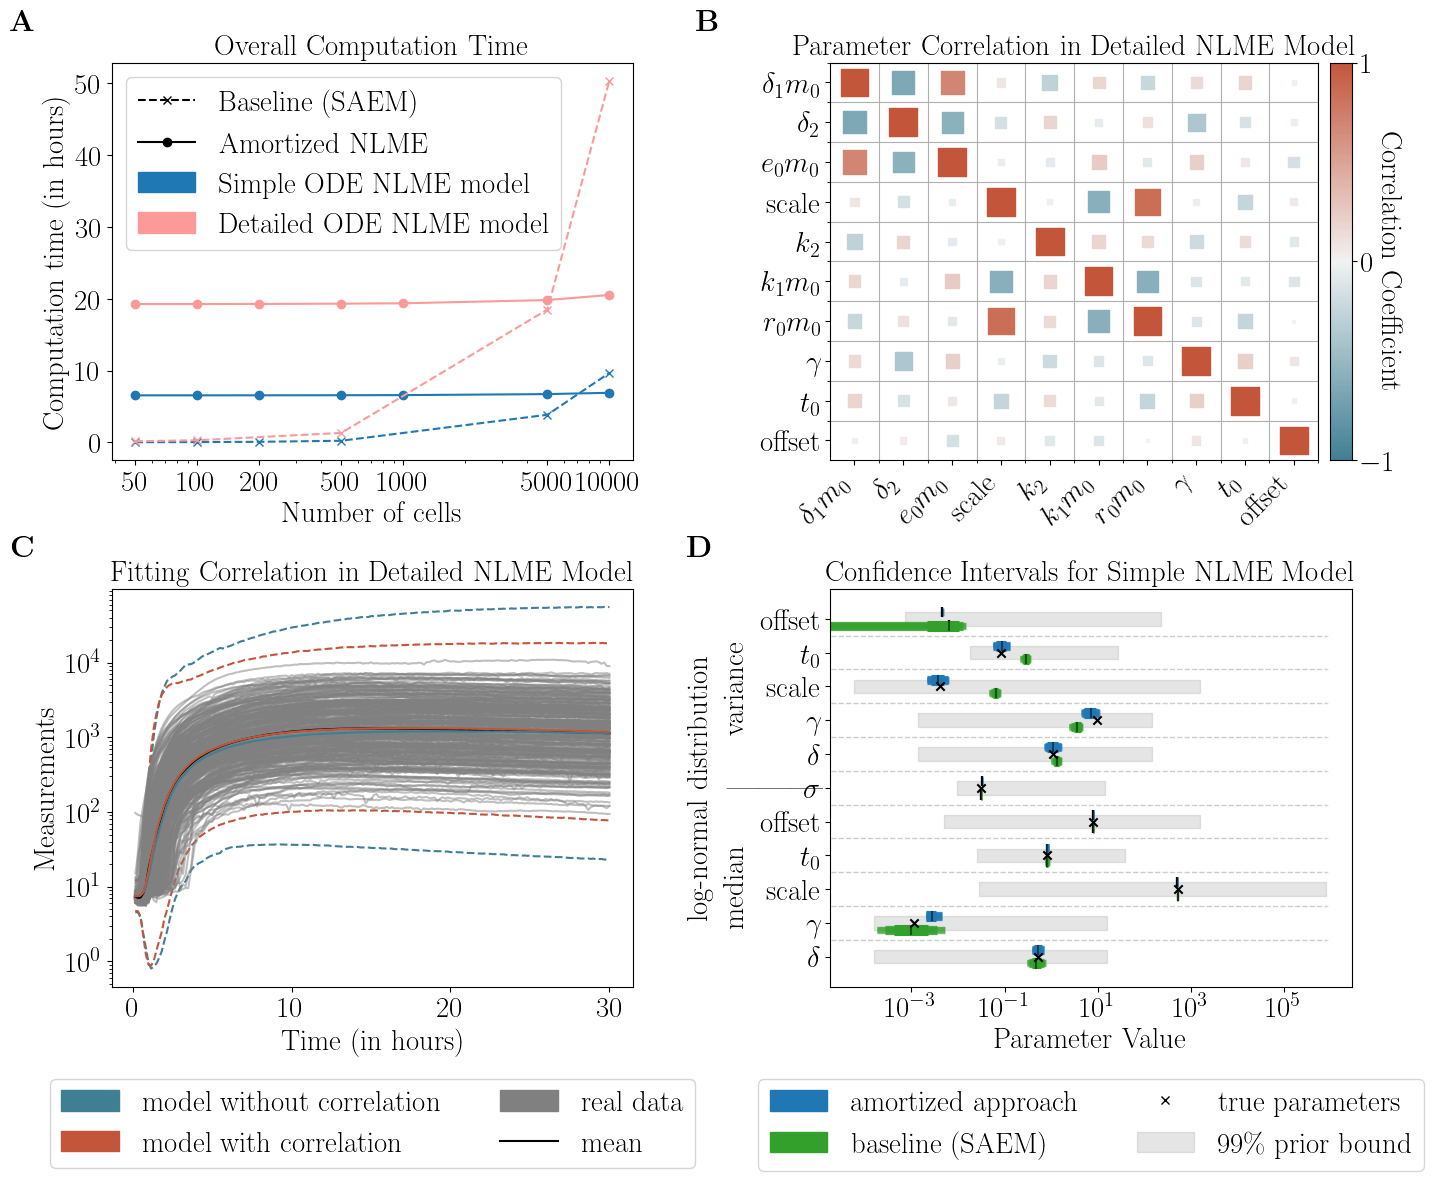

In [25]:
fig_total = plt.figure()#layout="tight")
grid = plt.GridSpec(3, 18, figure=fig_total, width_ratios=[1.5]+[0.5]+[1/16]*16, height_ratios=[1, 0.05, 1])
ax1 = fig_total.add_subplot(grid[0, 2:17])
ax2 = fig_total.add_subplot(grid[2, 0])
ax3 = fig_total.add_subplot(grid[0, 0])
ax4 = fig_total.add_subplot(grid[2, 2:])


###################### # Correlation Plot
ax1.set_title('Parameter Correlation in Detailed NLME Model')
corrplot(corr_df, ax=plt.subplot(grid[0, 2:17]), ax_2=plt.subplot(grid[0, 17]),
                   size_scale=400,)
ax1.set_ylabel('Correlation Coefficient', rotation=270, labelpad=60)
ax1.yaxis.set_label_position("right")

###################### population fit (no corr, corr)
# plot real synthetic data vs estimated data
colors_corr = [sns.diverging_palette(220, 20, n=256)[0], sns.diverging_palette(220, 20, n=256)[-1]]

t_points = np.linspace(start=1 / 6, stop=30, num=real_single_cell.shape[1], endpoint=True)

ax2.plot(t_points, np.exp(pop_spread_lower_no_corr.flatten()), '--', color=colors_corr[0]) #colors[1])
ax2.plot(t_points, np.exp(pop_spread_upper_no_corr.flatten()), '--', color=colors_corr[0]) #colors[1])
#ax2.fill_between(t_points,  np.exp(pop_spread_lower_no_corr.flatten()), 
#                 np.exp(pop_spread_upper_no_corr.flatten()),
#                 color=colors_corr[0], alpha=0.5)

ax2.plot(t_points, np.exp(pop_spread_lower_corr.flatten()), '--', color=colors_corr[1]) #colors[4])
ax2.plot(t_points, np.exp(pop_spread_upper_corr.flatten()), '--', color=colors_corr[1]) #colors[4])
#ax2.fill_between(t_points,  np.exp(pop_spread_lower_corr.flatten()), 
#                 np.exp(pop_spread_upper_corr.flatten()),
#                 color=colors_corr[1], alpha=0.5)

for cell in real_data[0]:
    ax2.plot(t_points, np.exp(cell), '-', color='grey', alpha=0.5, label='data')
    
ax2.plot(t_points, np.exp(real_mean), '-', color='black', label='mean')
ax2.plot(t_points, np.exp(np.mean(reproduced_data, axis=0)), color=colors_corr[0], #colors[1],
         label='without correlation')
ax2.plot(t_points, np.exp(np.mean(reproduced_data_d2, axis=0)), color=colors_corr[1], #colors[4],
         label='with correlation')

no_corr_patch = mpatches.Patch(color=colors_corr[0], label='model without correlation')
corr_patch = mpatches.Patch(color=colors_corr[1], label='model with correlation')
sample = mpatches.Patch(color='grey', label='data')
mean, = plt.plot([], [], '-', color='black', label='mean')
#spread, = plt.plot([], [], '--', color='black', label='95\% variance')
data_label = mpatches.Patch(color='grey', label='real data')
#data_label, = plt.plot([], [], '-', color='grey', label='real data')
ax2.legend(handles=[no_corr_patch, corr_patch, data_label, mean], ncol=2,
           loc='lower center', bbox_to_anchor=(0.5, -0.493))
ax2.set_yscale('log')
#ax2_lim = ax2.get_ylim()
#ax2.set_ylim([0.05, ax2_lim[1]])  # make legend visible
ax2.set_title('Fitting Correlation in Detailed NLME Model')
ax2.set_xlabel('Time (in hours)')
ax2.set_ylabel('Measurements')

###################### Scalability
ax3.set_title('Overall Computation Time')

### Time on Synthetic Data
#ax3.hlines(4.2, xmin=test_n_cells[0], xmax=test_n_cells[-1], color=colors[0], linestyle='-.')
#ax3.annotate('Average training time of BayesFlow', xy=(75, 5.2), fontsize=10, color=colors[0])
#ax3.hlines(13.64, xmin=test_n_cells[0], xmax=test_n_cells[-1], color=colors[1], linestyle='-.')
#ax3.annotate('Average training time of BayesFlow', xy=(75, 14.64), fontsize=10, color=colors[1])
#ax3.hlines(9.72, xmin=test_n_cells[0], xmax=test_n_cells[-1], color=colors[2], linestyle='-.')
#ax3.annotate('Average training time of BayesFlow', xy=(500, 10.72), fontsize=10, color=colors[2])

for j, n_samples_opt in enumerate([10, 50, 100]):
    if n_samples_opt != 100: continue
    ax3.plot(test_n_cells, time_opt_small[:, j], 'o-', color=colors[0])
#ax3.annotate(f' {10} samples', xy=(6500, time_opt_small[-1, 0]-0.075), fontsize=10, color=colors[0])
#ax_total[1, 1].annotate(f' {50} samples', xy=(6500, time_opt_small[-1, 1]/60/60), fontsize=10, color=colors[0])
#ax3.annotate(f'{100} samples', xy=(6500-350, time_opt_small[-1, 2]), fontsize=10, color=colors[0])
for j, n_samples_opt in enumerate([10, 50, 100]):
    if n_samples_opt != 100: continue
    ax3.plot(test_n_cells, time_opt_large[:, j], 'o-', color=colors[4])
#ax_total[1, 1].annotate(f' {10} samples', xy=(6500, time_opt_large[-1, 0]/60/60-0.02), fontsize=10, color=colors[1])
#ax_total[1, 1].annotate(f' {50} samples', xy=(6500, time_opt_large[-1, 1]/60/60+0.15), fontsize=10, color=colors[1])
#ax3.annotate(f'{100} samples', xy=(6500-350, time_opt_large[-1, 2]+0.3), fontsize=10, color=colors[1])
#for j, n_samples_opt in enumerate([10, 50, 100]):
#    if n_samples_opt != 100: continue
#    ax3.plot(test_n_cells, time_opt_sde[:, j], 'o-', color=colors[2])
#ax_total[1, 1].annotate(f'{10} samples', xy=(6500, time_opt_sde[-1, 0]/60/60-0.02), fontsize=10, color=colors[2])
#ax_total[1, 1].annotate(f'{50} samples', xy=(6500, time_opt_sde[-1, 1]/60/60-0.15), fontsize=10, color=colors[2])
#ax3.annotate(f'{100} samples', xy=(6500-350, time_opt_sde[-1, 2]+0.3), fontsize=10, color=colors[2])

ax3.plot(n_cells_opt_list_monolix_small, time_monolix_small, 'x--', color=colors[0]) #, label=f'baseline (small model)')
ax3.plot(n_cells_opt_list_monolix_large, time_monolix_large, 'x--', color=colors[4]) #, label=f'baseline (large model)')

ax3.set_ylabel('Computation time (in hours)')
ax3.set_xscale('log')
#ax3.set_yscale('log')

ax3.set_xlabel('Number of cells')
ax3.set_xticks(ticks=test_n_cells, labels=test_n_cells) #, rotation=60)

baseline, = ax3.plot([],[], 'x--',  color='black', label='Baseline (SAEM)')  # not visible
amortized, = ax3.plot([],[], 'o-',  color='black', label='Amortized NLME')  # not visible
small_patch = mpatches.Patch(color=colors[0], label='Simple ODE NLME model')
large_patch = mpatches.Patch(color=colors[4], label='Detailed ODE NLME model')
#sde_patch = mpatches.Patch(color=colors[2], label='SDE model')
ax3.legend(handles=[baseline, amortized, small_patch, large_patch, 
                    #sde_patch
                    ], loc='upper left')


###################### Uncertainty
ax4.set_title('Confidence Intervals for Simple NLME Model')

offset = 0.2
# plot boundaries
for i in range(n_opt_param - 1):
    #ax4.vlines(np.exp(lower_bound[i]), i - offset, i + offset, color='black', alpha=0.5)
    #ax4.vlines(np.exp(upper_bound[i]), i - offset, i + offset, color='black', alpha=0.5)
    ax4.fill_betweenx([i - offset, i + offset], np.exp(lower_bound[i]), np.exp(upper_bound[i]),
                      color='grey', alpha=0.2)

plot_intervals(transformed_monolix_median,
               transformed_monolix_intervals[0],
               ax=ax4,
               alpha_median=0.5,
               par_names=param_names_plot[:-1],
               levels=[0.2, 0.05, 0.01, 0.99, 0.95, 0.8],
               offset=-offset,
               color=colors[3])
plot_intervals(np.median(transformed_intervals, axis=1),
               transformed_intervals,
               ax=ax4, alpha_median=0.5,
               par_names=param_names_plot[:-1],
               levels=[0.2, 0.05, 0.01, 0.99, 0.95, 0.8],
               offset=offset,
               color=colors[0])

ax4.scatter(transformed_true_params[:-1], np.arange(n_opt_param - 1),
           c='black', marker='x', label='True Parameters', zorder=2)
ax4.set_yticks(ticks=np.arange(n_opt_param - 1), labels=np.array(param_names_plot[:-1]))
ax4.set_xlabel('Parameter Value')
ax4.set_xscale('log')

true_params, = ax4.plot([], [], 'x', color='black', label='True Parameters')  # not visible
baseline = mpatches.Patch(color=colors[3], label='Baseline (SAEM)')
amortized = mpatches.Patch(color=colors[0], label='Amortized NLME')
prior_range = mpatches.Patch(color='grey', alpha=0.2, label='99\% Prior Bound')
ax4.legend(handles=[amortized, baseline, true_params, prior_range], loc='lower center',
           bbox_to_anchor=(0.5, -0.5), ncols=2)

# more comprehensive y labels
plt.text(-0.25, 0.5, 'log-normal distribution', horizontalalignment='center',
     verticalalignment='center', transform=ax4.transAxes, rotation=90, fontsize='small')
plt.text(-0.18, 0.75, 'variance', horizontalalignment='center',
     verticalalignment='center', transform=ax4.transAxes, rotation=90, fontsize='small')
plt.text(-0.18, 0.25, 'median', horizontalalignment='center',
     verticalalignment='center', transform=ax4.transAxes, rotation=90, fontsize='small')
plt.text(-0.2, 0.52, '---------', horizontalalignment='left',
     verticalalignment='center', transform=ax4.transAxes)

ax1.text(-0.25, 1.1, '\\bf{B}', horizontalalignment='center', verticalalignment='center',
         transform=ax1.transAxes, fontsize=22)
ax2.text(-0.17, 1.1, '\\bf{C}', horizontalalignment='center', verticalalignment='center',
         transform=ax2.transAxes, fontsize=22)
ax3.text(-0.17, 1.1, '\\bf{A}', horizontalalignment='center', verticalalignment='center',
         transform=ax3.transAxes, fontsize=22)
ax4.text(-0.25, 1.1, '\\bf{D}', horizontalalignment='center', verticalalignment='center',
         transform=ax4.transAxes, fontsize=22)
#plt.savefig('plots/results_plot2.pdf', format='pdf', bbox_inches='tight',
#            dpi=600)
plt.show()

 # Compare SDE and ODE model on synthetic data

In [26]:
from models.froehlich_model_small import FroehlichModelSmall
model_small = FroehlichModelSmall(load_best=True)
path_store_network = 'networks/' + model_small.network_name
simulator_small = model_small.build_simulator(with_noise=False)
_ = model_small.build_trainer(path_store_network)

from models.froehlich_model_sde import FroehlichModelSDE
model_sde = FroehlichModelSDE(load_best=True)
path_store_network = 'networks/' + model_sde.network_name
simulator_sde = model_sde.build_simulator(with_noise=False)
_ = model_sde.build_trainer(path_store_network)

#sde_obs_data, _ = model.load_data(n_data=100, load_eGFP=True, load_d2eGFP=False)
sde_obs_data, _ = model_sde.load_data(n_data=500, load_eGFP=False, load_d2eGFP=False)

obj_fun_amortized = ObjectiveFunctionNLME(model_name=model_small.name,
                                          param_samples=np.empty((1,1,1)),
                                          prior_mean=model_small.prior_mean,
                                          prior_std=model_small.prior_std,
                                          covariance_format='diag',
                                          # np.exp(-3.41) * 1.5  # 1.5 times the median of the posterior standard deviations
                                          penalize_correlations=None,
                                          huber_loss_delta=None)
obj_fun_amortized_sde = ObjectiveFunctionNLME(model_name=model_sde.name,
                                          param_samples=np.empty((1,1,1)),
                                          prior_mean=model_sde.prior_mean,
                                          prior_std=model_sde.prior_std,
                                          covariance_format='diag',
                                          # np.exp(-3.41) * 1.5  # 1.5 times the median of the posterior standard deviations
                                          penalize_correlations=None,
                                          huber_loss_delta=None)

#result_small = read_from_hdf5.read_result('output/multi-experiment/fröhlich-small_cholesky_0.5')
result_small = read_from_hdf5.read_result('output/sde-comparison/FroehlichModelSmall_cells_500.hd5')
param_idx_egfp = [i_n for i_n, name in enumerate(result_small.problem.x_names) if 'd2eGFP' not in name]
result_small = result_small.optimize_result.as_dataframe()['x'][0][param_idx_egfp]

estimated_beta = result_small[:model_small.n_params]
estimated_psi = obj_fun_amortized.get_covariance(result_small[model_small.n_params:])


#result_sde = read_from_hdf5.read_result('output/multi-experiment/fröhlich-sde_cholesky_0.5')
result_sde = read_from_hdf5.read_result('output/sde-comparison/FroehlichModelSDE_cells_500.hd5')
param_idx_egfp = [i_n for i_n, name in enumerate(result_sde.problem.x_names) if 'd2eGFP' not in name]
result_sde = result_sde.optimize_result.as_dataframe()['x'][0][param_idx_egfp]

estimated_beta_sde = result_sde[:model_sde.n_params]
estimated_psi_sde = obj_fun_amortized_sde.get_covariance(result_sde[model_sde.n_params:])

np.random.seed(42)
# sample from log normal distribution
n_trajectories = len(sde_obs_data)
reproduced_param = np.random.multivariate_normal(estimated_beta,
                                                     estimated_psi,
                                                     size=n_trajectories*10)
reproduced_param_sde = np.random.multivariate_normal(estimated_beta_sde,
                                                        estimated_psi_sde,
                                                        size=n_trajectories*10)

reproduced_data = simulator_small(reproduced_param)['sim_data']
reproduced_data_sde = simulator_sde(reproduced_param_sde)['sim_data']

real_mean = np.mean(sde_obs_data, axis=0)
real_var = np.var(sde_obs_data, axis=0)
dif_small = np.mean(reproduced_data, axis=0) - real_mean
dif_var_small = np.var(reproduced_data, axis=0) - real_var
std_small = np.std(reproduced_data, axis=0)

dif_sde = np.mean(reproduced_data_sde, axis=0) - real_mean
dif_var_sde = np.var(reproduced_data_sde, axis=0) - real_var
std_sde = np.std(reproduced_data_sde, axis=0)

t_value_05 = abs(t_dist.ppf(0.05 / reproduced_data.shape[1], df=reproduced_data.shape[0] - 1))

confidence_band_upper = dif_small + t_value_05 * std_small / np.sqrt(reproduced_data.shape[0])
confidence_band_lower = dif_small - t_value_05 * std_small / np.sqrt(reproduced_data.shape[0])
confidence_band_upper_sde = dif_sde + t_value_05 * std_sde / np.sqrt(reproduced_data.shape[0])
confidence_band_lower_sde = dif_sde - t_value_05 * std_sde / np.sqrt(reproduced_data.shape[0])

INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 6)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 180, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


using LSTM with 256 units as summary network
using a 6-layer cINN as inference network
prior mean: [-3 -3  5  0  1 -1]
prior covariance diagonal: [ 5  5 11  2  6  2]
Using the small Froehlich model


INFO:root:Loaded loss history from networks/amortizer-small-fro-6layers-LSTM-500epochs/history_512.pkl.
INFO:root:Loaded simulation memory from networks/amortizer-small-fro-6layers-LSTM-500epochs/memory.pkl
INFO:root:Networks loaded from networks/amortizer-small-fro-6layers-LSTM-500epochs/ckpt-512
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


Model: "amortized_posterior_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 invertible_network_7 (Inver  multiple                 1204440   
 tibleNetwork)                                                   
                                                                 
 lstm_7 (LSTM)               multiple                  264192    
                                                                 
Total params: 1,468,632
Trainable params: 1,468,560
Non-trainable params: 72
_________________________________________________________________
None
using 2 layers of MultiConv1D,a LSTM with 256 units and a dense layer with output dimension 20 as summary network
using a 7-layer cINN as inference network
prior mean: [-3 -3 -1  5  0  0  1 -3]
prior covariance diagonal: [5 5 5 5 5 2 5 2]
Using the SDE version of the Froehlich model


INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 8)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 180, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.
INFO:root:Loaded loss history from networks/amortizer-sde-fro-7layers-1000epochs/history_1000.pkl.
INFO:root:Loaded simulation memory from networks/amortizer-sde-fro-7layers-1000epochs/memory.pkl
INFO:root:Networks loaded from networks/amortizer-sde-fro-7layers-1000epochs/ckpt-1000
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


Model: "amortized_posterior_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 invertible_network_8 (Inver  multiple                 566608    
 tibleNetwork)                                                   
                                                                 
 sequential_network_2 (Seque  multiple                 308532    
 ntialNetwork)                                                   
                                                                 
Total params: 875,140
Trainable params: 875,028
Non-trainable params: 112
_________________________________________________________________
None


This problem is not to be used without a separately created objective.
INFO:pypesto.store.read_from_hdf5:WARNING: You are loading a problem.
This problem is not to be used without a separately created objective.
Loading the profiling result failed. It is highly likely that no profiling result exists within output/sde-comparison/FroehlichModelSmall_cells_500.hd5.
Loading the sampling result failed. It is highly likely that no sampling result exists within output/sde-comparison/FroehlichModelSmall_cells_500.hd5.
This problem is not to be used without a separately created objective.
INFO:pypesto.store.read_from_hdf5:WARNING: You are loading a problem.
This problem is not to be used without a separately created objective.
Loading the profiling result failed. It is highly likely that no profiling result exists within output/sde-comparison/FroehlichModelSDE_cells_500.hd5.
Loading the sampling result failed. It is highly likely that no sampling result exists within output/sde-comparison/Froeh

In [27]:
print(real_mean[-1],  dif_small[-1]+real_mean[-1], dif_sde[-1]+real_mean[-1])
print(real_var[-1],  
      (dif_var_small[-1]+real_var[-1])/real_var[-1], 
      (dif_var_sde[-1]+real_var[-1])/real_var[-1])

[6.98397377] [7.00349045] [6.97358036]
[2.04133749] [2.93629799] [1.39102487]


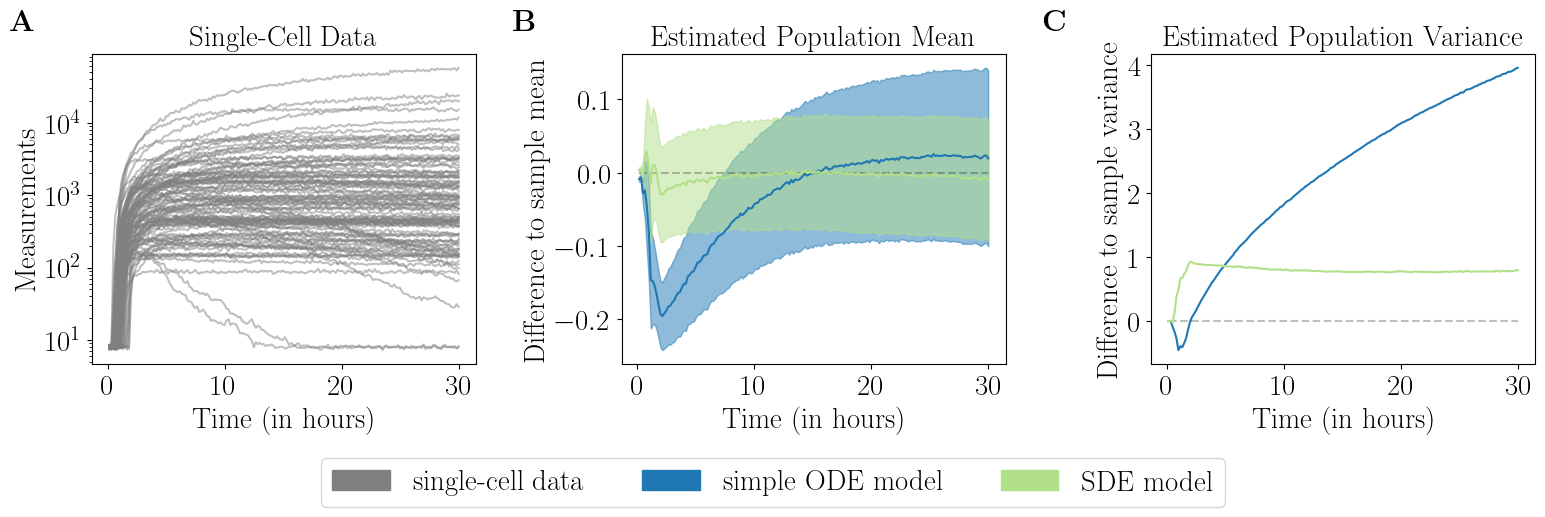

In [29]:
#plt.figure(layout='tight', figsize=(6,5))
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 5), layout="tight")
# plot real synthetic data vs estimated data
t_points = np.linspace(start=1 / 6, stop=30, num=real_data[0].shape[1], endpoint=True)


ax[0].set_title('Single-Cell Data')
for i, cell in enumerate(sde_obs_data):
    if i > 100: break
    ax[0].plot(t_points, np.exp(cell.flatten()), color='grey', alpha=0.5)
ax[0].set_xlabel('Time (in hours)')
ax[0].set_ylabel('Measurements')
ax[0].set_yscale('log')

ax[1].fill_between(t_points, confidence_band_upper.flatten(), confidence_band_lower.flatten(),
                         color=colors[0], alpha=0.5, label='ODE')#, label='95\% confidence band')
ax[1].plot(t_points, dif_small, color=colors[0])
ax[1].plot(t_points, np.zeros(t_points.size), color='black', linestyle='--', alpha=0.25)

ax[1].fill_between(t_points, confidence_band_upper_sde.flatten(), confidence_band_lower_sde.flatten(),
                         color=colors[2], alpha=0.5, label='SDE')#, label='95\% confidence band')
ax[1].plot(t_points, dif_sde, color=colors[2])


#ax[1].fill_between(t_points, confidence_band_upper.flatten(), confidence_band_lower.flatten(),
#                         color=colors[0], alpha=0.5, label='ODE')#, label='95\% confidence band')
ax[2].plot(t_points, dif_var_small, color=colors[0])
ax[2].plot(t_points, np.zeros(t_points.size), color='black', linestyle='--', alpha=0.25)

#ax[1].fill_between(t_points, confidence_band_upper_sde.flatten(), confidence_band_lower_sde.flatten(),
#                         color=colors[2], alpha=0.5, label='SDE')#, label='95\% confidence band')
ax[2].plot(t_points, dif_var_sde, color=colors[2])

ax[1].set_title('Estimated Population Mean')
ax[2].set_title('Estimated Population Variance')
#ax6.set_title('Large ODE Model with Correlation')
ax[1].set_ylabel('Difference to sample mean')
ax[2].set_ylabel('Difference to sample variance')
ax[1].set_xlabel('Time (in hours)')
ax[2].set_xlabel('Time (in hours)')
#ax[0].legend()

real_measurement = mpatches.Patch(color='grey', label='Single-cell data')
ode_patch = mpatches.Patch(color=colors[0], label='Simple ODE model')
sde_patch = mpatches.Patch(color=colors[2], label='SDE model')
lgd = fig.legend(handles=[real_measurement, ode_patch, sde_patch],
            loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.1))

ax[0].text(-0.18, 1.1, '\\bf{A}', horizontalalignment='center', verticalalignment='center',
           transform=ax[0].transAxes, fontsize=22)
ax[1].text(-0.25, 1.1, '\\bf{B}', horizontalalignment='center', verticalalignment='center',
           transform=ax[1].transAxes, fontsize=22)
ax[2].text(-0.25, 1.1, '\\bf{C}', horizontalalignment='center', verticalalignment='center',
           transform=ax[2].transAxes, fontsize=22)

#plt.savefig('plots/sde_vs_ode.pdf', format='pdf', bbox_inches='tight',  pad_inches=0.2,
#            bbox_extra_artists=(lgd,), dpi=600)

plt.show()

# Uncertainty Analysis

In [37]:
from models.froehlich_model_large import FroehlichModelLarge
model_large = FroehlichModelLarge(load_best=True)
param_names = model_large.param_names.copy()
#param_names[2] = 'scale'
pop_param_names = ['median-' + name for name in param_names] #['pop-' + name for name in model.param_names]
var_param_names = ['var-' + name for name in param_names]
param_names_plot_large = param_names + param_names # pop_param_names + var_param_names

n_data = 50
_, true_sample_params = model_large.load_data(n_data=n_data, load_eGFP=False, load_d2eGFP=False)
result_optimization = read_from_hdf5.read_result(f'output/uncertainty/{model_large.name}_cells_{n_data}_samples_{50}.hd5')

# compute confidence intervals and save them
profile_list = result_optimization.profile_result.list[0]
profile_indices = [ix for ix, res in enumerate(profile_list) if res]

intervals_large = []
for i_par in range(result_optimization.problem.dim_full):
    if i_par not in profile_indices:
        continue
    xs = profile_list[i_par].x_path[i_par]
    ratios = profile_list[i_par].ratio_path
    lb_01, ub_01 = profile.calculate_approximate_ci(
        xs=xs, ratios=ratios, confidence_ratio=profile.chi2_quantile_to_ratio(0.99)
    )
    lb_05, ub_05 = profile.calculate_approximate_ci(
        xs=xs, ratios=ratios, confidence_ratio=profile.chi2_quantile_to_ratio(0.95)
    )
    lb_2, ub_2 = profile.calculate_approximate_ci(
        xs=xs, ratios=ratios, confidence_ratio=profile.chi2_quantile_to_ratio(0.80)
    )
    if i_par < model_large.n_params:
        intervals_large.append((lb_2, lb_05, lb_01, ub_01, ub_05, ub_2))
    else:
        intervals_large.append((np.exp(-ub_2), np.exp(-ub_05), np.exp(-ub_01), np.exp(-lb_01), np.exp(-lb_05), np.exp(-lb_2)))
intervals_large = np.array(intervals_large)

transformed_intervals_large = np.concatenate((np.exp(intervals_large[:model_large.n_params]),
                                                intervals_large[model_large.n_params:]))
transformed_true_params_large = np.concatenate((np.exp(true_sample_params[:model_large.n_params]),
                                          true_sample_params[model_large.n_params:]))

lower_bound_large, upper_bound_large = create_boundaries_from_prior(
        prior_mean=model_large.prior_mean,
        prior_std=model_large.prior_std,
        boundary_width_from_prior=2.58,  # 99% of the prior mass is within 2.58 standard deviations
        covariance_format='diag'
)

## sde model
from models.froehlich_model_sde import FroehlichModelSDE
model_sde = FroehlichModelSDE(load_best=True)
param_names = model_sde.param_names.copy()
#param_names[2] = 'scale'
pop_param_names = ['median-' + name for name in param_names] #['pop-' + name for name in model.param_names]
var_param_names = ['var-' + name for name in param_names]
param_names_plot_sde = param_names + param_names # pop_param_names + var_param_names

n_data = 50
_, true_sample_params = model_sde.load_data(n_data=n_data, load_eGFP=False, load_d2eGFP=False)
result_optimization = read_from_hdf5.read_result(f'output/uncertainty/{model_sde.name}_cells_{n_data}_samples_{50}.hd5')

# compute confidence intervals and save them
profile_list = result_optimization.profile_result.list[0]
profile_indices = [ix for ix, res in enumerate(profile_list) if res]

intervals_sde = []
for i_par in range(result_optimization.problem.dim_full):
    if i_par not in profile_indices:
        continue
    xs = profile_list[i_par].x_path[i_par]
    ratios = profile_list[i_par].ratio_path
    lb_01, ub_01 = profile.calculate_approximate_ci(
        xs=xs, ratios=ratios, confidence_ratio=profile.chi2_quantile_to_ratio(0.99)
    )
    lb_05, ub_05 = profile.calculate_approximate_ci(
        xs=xs, ratios=ratios, confidence_ratio=profile.chi2_quantile_to_ratio(0.95)
    )
    lb_2, ub_2 = profile.calculate_approximate_ci(
        xs=xs, ratios=ratios, confidence_ratio=profile.chi2_quantile_to_ratio(0.80)
    )
    if i_par < model_sde.n_params:
        intervals_sde.append((lb_2, lb_05, lb_01, ub_01, ub_05, ub_2))
    else:
        intervals_sde.append((np.exp(-ub_2), np.exp(-ub_05), np.exp(-ub_01), np.exp(-lb_01), np.exp(-lb_05), np.exp(-lb_2)))
intervals_sde = np.array(intervals_sde)

transformed_intervals_sde = np.concatenate((np.exp(intervals_sde[:model_sde.n_params]),
                                                intervals_sde[model_sde.n_params:]))
transformed_true_params_sde = np.concatenate((np.exp(true_sample_params[:model.n_params]),
                                          true_sample_params[model.n_params:]))

lower_bound_sde, upper_bound_sde = create_boundaries_from_prior(
        prior_mean=model_sde.prior_mean,
        prior_std=model_sde.prior_std,
        boundary_width_from_prior=2.58,  # 99% of the prior mass is within 2.58 standard deviations
        covariance_format='diag'
)

using LSTM with 256 units as summary network
using a 9-layer cINN as inference network
prior mean: [ 0 -1  0 12  0  1 -3 -6  0  2 -1]
prior covariance diagonal: [5. 5. 2. 1. 2. 2. 2. 5. 2. 6. 2.]
Using the large Froehlich model


This problem is not to be used without a separately created objective.
INFO:pypesto.store.read_from_hdf5:WARNING: You are loading a problem.
This problem is not to be used without a separately created objective.
Loading the optimization result failed. It is highly likely that no optimization result exists within output/uncertainty/FroehlichModelLarge_cells_50_samples_50.hd5.
Loading the sampling result failed. It is highly likely that no sampling result exists within output/uncertainty/FroehlichModelLarge_cells_50_samples_50.hd5.


using 2 layers of MultiConv1D,a LSTM with 256 units and a dense layer with output dimension 20 as summary network
using a 7-layer cINN as inference network
prior mean: [-3 -3 -1  5  0  0  1 -3]
prior covariance diagonal: [5 5 5 5 5 2 5 2]
Using the SDE version of the Froehlich model


This problem is not to be used without a separately created objective.
INFO:pypesto.store.read_from_hdf5:WARNING: You are loading a problem.
This problem is not to be used without a separately created objective.
Loading the optimization result failed. It is highly likely that no optimization result exists within output/uncertainty/FroehlichModelSDE_cells_50_samples_50.hd5.
Loading the sampling result failed. It is highly likely that no sampling result exists within output/uncertainty/FroehlichModelSDE_cells_50_samples_50.hd5.


/var/folders/6l/dj45z5dn7zn0djmp1vjb65bh0000gn/T/ipykernel_3545/3582533774.py:95: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.savefig('plots/uncertainty_cell_models.pdf', format='pdf', pad_inches=1,
/Users/jonas.arruda/miniconda/envs/AmortizedNLMEs/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


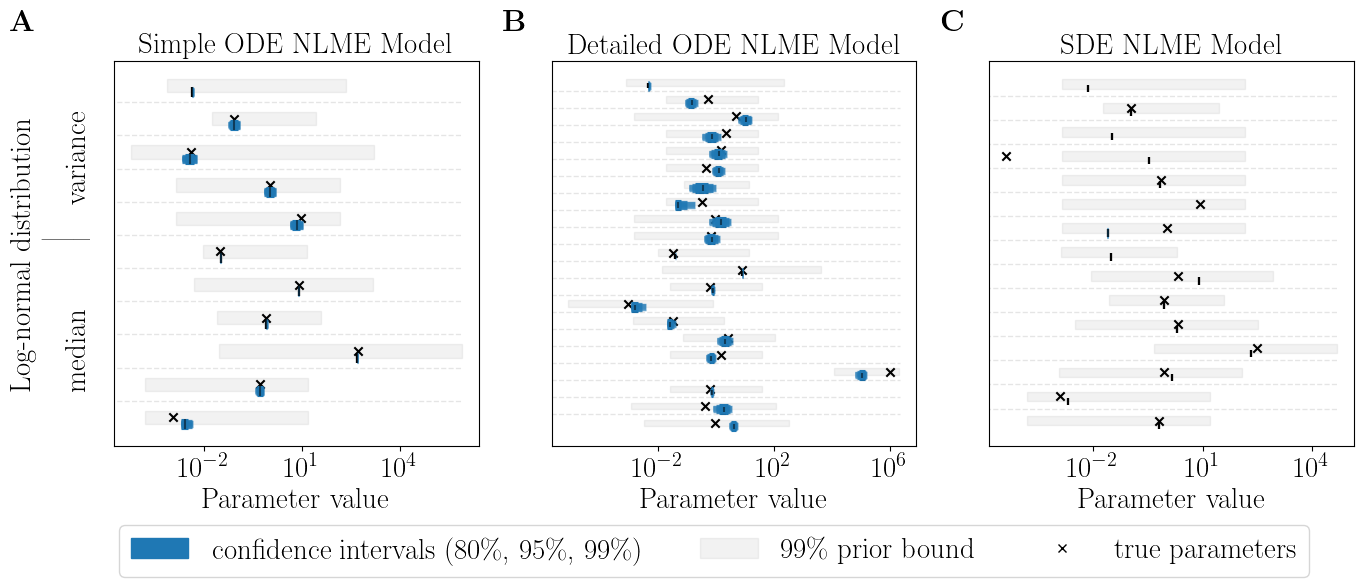

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 5), layout="tight")
ax[0].set_title('Simple ODE Model')

offset = 0.2

# plot boundaries
for i in range(model_small.n_params * 2 - 1):
    ax[0].fill_betweenx([i - offset, i + offset], np.exp(lower_bound[i]), np.exp(upper_bound[i]),
                      color='grey', alpha=0.1)

rearange_index = [1,0,2,3,4,5,7,6,8,9,10] # to avoid overlapping of labels
plot_intervals(np.median(transformed_intervals, axis=1)[rearange_index],
               transformed_intervals[rearange_index],
               ax=ax[0],
               alpha=0.3,
               par_names=np.array(param_names_plot[:-1])[rearange_index],
               levels=[0.2, 0.05, 0.01, 0.99, 0.95, 0.8],
               offset=-offset,
               color=colors[0])

ax[0].scatter(transformed_true_params[:-1][rearange_index], np.arange(model_small.n_params * 2 - 1),
           c='black', marker='x', label='True Parameters')
ax[0].set_yticks([],[]) #ticks=np.arange(model_small.n_params * 2 - 1), labels=np.array(param_names_plot[:-1])[rearange_index])
ax[0].set_xlabel('Parameter Value')
ax[0].set_xscale('log')

ax[1].set_title('Detailed ODE Model')
for i in range(model_large.n_params * 2 - 1):
    ax[1].fill_betweenx([i - offset, i + offset], np.exp(lower_bound_large[i]), np.exp(upper_bound_large[i]),
                      color='grey', alpha=0.1)
plot_intervals(np.median(transformed_intervals_large, axis=1),
               transformed_intervals_large,
               ax=ax[1],
               alpha=0.3,
               par_names=param_names_plot_large[:-1],
               levels=[0.2, 0.05, 0.01, 0.99, 0.95, 0.8],
               offset=-offset,
               color=colors[0])


ax[1].scatter(transformed_true_params_large[:-1], np.arange(model_large.n_params * 2 - 1),
           c='black', marker='x', label='True Parameters')
ax[1].set_yticks([],[]) #ticks=np.arange(model.n_params * 2 - 1), labels=param_names_plot_large[:-1])
ax[1].set_xlabel('Parameter Value')
ax[1].set_xscale('log')


ax[2].set_title('SDE Model')
for i in range(model_sde.n_params * 2 - 1):
    ax[2].fill_betweenx([i - offset, i + offset], np.exp(lower_bound_sde[i]), np.exp(upper_bound_sde[i]),
                      color='grey', alpha=0.1)
plot_intervals(np.median(transformed_intervals_sde, axis=1),
               transformed_intervals_sde,
               ax=ax[2],
               alpha=0.3,
               par_names=param_names_plot_sde[:-1],
               levels=[0.2, 0.05, 0.01, 0.99, 0.95, 0.8],
               offset=-offset,
               color=colors[0])

ax[2].scatter(transformed_true_params_sde[:-1], np.arange(model_sde.n_params * 2 - 1),
           c='black', marker='x', label='True Parameters')
ax[2].set_yticks([],[]) #ticks=np.arange(model_sde.n_params * 2 - 1), labels=param_names_plot_sde[:-1])
ax[2].set_xlabel('Parameter Value')
ax[2].set_xscale('log')


true_params, = ax[0].plot([], [], 'x', color='black', label='True Parameters')  # not visible
#baseline = mpatches.Patch(color=colors[3], label='Baseline (SAEM)')
amortized = mpatches.Patch(color=colors[0], label='Confidence Intervals (80\%, 95\%, 99\%)')
prior_range = mpatches.Patch(color='grey', alpha=0.1, label='99\% Prior Bound')
#ax[0].legend(handles=[amortized, baseline, prior_range, true_params], loc='upper right')

lgd = fig.legend(handles=[amortized, prior_range, true_params],
            loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.18))

# more comprehensive y labels
plt.text(-0.25, 0.5, 'log-normal distribution', horizontalalignment='center',
     verticalalignment='center', transform=ax[0].transAxes, rotation=90, fontsize='small')
plt.text(-0.1, 0.75, 'variance', horizontalalignment='center',
     verticalalignment='center', transform=ax[0].transAxes, rotation=90, fontsize='small')
plt.text(-0.1, 0.25, 'median', horizontalalignment='center',
     verticalalignment='center', transform=ax[0].transAxes, rotation=90, fontsize='small')
plt.text(-0.2, 0.56, '-----', horizontalalignment='left',
     verticalalignment='center', transform=ax[0].transAxes)


ax[0].text(-0.25, 1.1, '\\bf{A}', horizontalalignment='center', verticalalignment='center',
           transform=ax[0].transAxes, fontsize=22)
ax[1].text(-0.1, 1.1, '\\bf{B}', horizontalalignment='center', verticalalignment='center',
           transform=ax[1].transAxes, fontsize=22)
ax[2].text(-0.1, 1.1, '\\bf{C}', horizontalalignment='center', verticalalignment='center',
           transform=ax[2].transAxes, fontsize=22)

#plt.savefig('plots/uncertainty_cell_models.pdf', format='pdf', pad_inches=1,
#            bbox_inches='tight', bbox_extra_artists=(lgd,), dpi=600)

plt.show()

# Analyze SDE model

In [41]:
from models.froehlich_model_sde import FroehlichModelSDE
sde_model = FroehlichModelSDE(load_best=True)

sde_simulator = sde_model.build_simulator()
trainer = sde_model.build_trainer('networks/' + sde_model.network_name)

obs_data, true_pop_parameters = sde_model.load_data(n_data=500, load_eGFP=True, load_d2eGFP=False)
data = obs_data[5, :][np.newaxis, :]
param_samples = sde_model.draw_posterior_samples(data=data, n_samples=1000)

syn_sim = sde_simulator(param_samples)['sim_data']
# compute mean and 95% credible region
syn_median = np.median(syn_sim, axis=0)
syn_perc = np.percentile(syn_sim.reshape(syn_sim.shape[0], 180), (5, 95), axis=0)

# compute simulations from median made only by model
param_median = np.median(param_samples, axis=0)[np.newaxis]
param_samples_median = np.repeat(param_median, 1000, axis=0)
simulation_median = sde_simulator(param_samples_median)['sim_data']
#syn_perc_median = np.percentile(simulation_median.reshape(simulation_median.shape[0], 180), (5, 95), axis=0)

t_points = np.linspace(start=1 / 6, stop=30, num=sde_model.n_obs, endpoint=True)

INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 8)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 180, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


using 2 layers of MultiConv1D,a LSTM with 256 units and a dense layer with output dimension 20 as summary network
using a 7-layer cINN as inference network
prior mean: [-3 -3 -1  5  0  0  1 -3]
prior covariance diagonal: [5 5 5 5 5 2 5 2]
Using the SDE version of the Froehlich model


INFO:root:Loaded loss history from networks/amortizer-sde-fro-7layers-1000epochs/history_1000.pkl.
INFO:root:Loaded simulation memory from networks/amortizer-sde-fro-7layers-1000epochs/memory.pkl
INFO:root:Networks loaded from networks/amortizer-sde-fro-7layers-1000epochs/ckpt-1000
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


Model: "amortized_posterior_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 invertible_network_13 (Inve  multiple                 566608    
 rtibleNetwork)                                                  
                                                                 
 sequential_network_5 (Seque  multiple                 308532    
 ntialNetwork)                                                   
                                                                 
Total params: 875,140
Trainable params: 875,028
Non-trainable params: 112
_________________________________________________________________
None


In [ ]:
obj_fun_amortized = ObjectiveFunctionNLME(model_name=model_small.name,
                                          param_samples=np.empty((1,1,1)),
                                          prior_mean=model_small.prior_mean,
                                          prior_std=model_small.prior_std,
                                          covariance_format='cholesky',
                                          # np.exp(-3.41) * 1.5  # 1.5 times the median of the posterior standard deviations
                                          penalize_correlations=None,
                                          huber_loss_delta=None)

result_small = read_from_hdf5.read_result('output/multi-experiment/fröhlich-small_cholesky_0.5') # _test_full.hd5
param_idx_egfp = [i_n for i_n, name in enumerate(result_small.problem.x_names) if 'd2eGFP' not in name]
result_small = result_small.optimize_result.as_dataframe()['x'][0][param_idx_egfp]
estimated_beta = result_small[:6]
estimated_psi = obj_fun_amortized.get_covariance(result_small[6:])

obj_fun_amortized_sde_corr = ObjectiveFunctionNLME(model_name=model_sde.name,
                                          param_samples=np.empty((1,1,1)),
                                          prior_mean=model_sde.prior_mean,
                                          prior_std=model_sde.prior_std,
                                          covariance_format='cholesky',
                                          # np.exp(-3.41) * 1.5  # 1.5 times the median of the posterior standard deviations
                                          penalize_correlations=None,
                                          huber_loss_delta=None)
result_sde = read_from_hdf5.read_result('output/multi-experiment/fröhlich-sde_cholesky_0.5')
#result_sde = read_from_hdf5.read_result('output/multi-experiment/fröhlich-sde_diag_0.hd5')
param_idx_egfp = [i_n for i_n, name in enumerate(result_sde.problem.x_names) if 'd2eGFP' not in name]
result_sde = result_sde.optimize_result.as_dataframe()['x'][0][param_idx_egfp]
estimated_beta_sde_corr = result_sde[:8]
estimated_psi_sde_corr = obj_fun_amortized_sde_corr.get_covariance(result_sde[8:])

In [ ]:
fig = plt.figure(layout="tight", figsize=(16,6))
grid = plt.GridSpec(2, 3, figure=fig, wspace=0.3, hspace=0.4, width_ratios=[1,0.5,0.5])
axis_joint = fig.add_subplot(grid[1, 2])
axis_fit = fig.add_subplot(grid[:2, 0])
zax = axis_fit.inset_axes([0.4, 0.2, 0.45, 0.45])

axis_sde1 = fig.add_subplot(grid[0, 1], sharex=axis_joint, sharey=axis_joint)
axis_sde2 = fig.add_subplot(grid[0, 2], sharex=axis_sde1, sharey=axis_sde1)
axis_sde3 = fig.add_subplot(grid[1, 1], sharex=axis_sde2, sharey=axis_sde2)


region = axis_fit.fill_between(t_points, np.exp(syn_perc[0, :]), np.exp(syn_perc[1, :]), color=colors[2], alpha=0.2, label=f'95\% credible region')
zax.fill_between(t_points, np.exp(syn_perc[0, :]), np.exp(syn_perc[1, :]), color=colors[2], alpha=0.2, label=f'95\% credible region')

for sim_i, sim in enumerate(simulation_median):
    axis_fit.plot(t_points, np.exp(sim), alpha=0.5, c=colors[2])
    zax.plot(t_points, np.exp(sim), alpha=0.5, c=colors[2])
    if sim_i > 10:
        break
    #plt.fill_between(t_points, np.exp(syn_perc_median[0, :]), np.exp(syn_perc_median[1, :]), color='blue', alpha=0.2, label=f'model variance')
axis_fit.plot([], [], c='black', label=f'median')
measurements = axis_fit.scatter(t_points, np.exp(data.flatten()), c='red', marker='o', label=f'single cell measurements')
zax.scatter(t_points, np.exp(data.flatten()), c='red', marker='o')

zax.set_yscale('log')
zax.set_xlim(8,16)
zax.set_ylim(8e2,3e3)
zax.set_xticks([], labels=[])
zax.set_yticks([], labels=[], minor=True)
zax.set_yticks([])
axis_fit.indicate_inset_zoom(zax, edgecolor="black")

axis_fit.set_xlabel('Time (in hours)')
axis_fit.set_ylabel('Measurements')
axis_fit.set_yscale('log')
axis_fit.set_title('Cell-Specific Posterior Samples')


index_params = [2,3,4]
p_names = ['$k$', '$m_0$', '$\\textrm{scale}$']
for a_i, ax in enumerate([axis_sde1, axis_sde2, axis_sde3]):
    xmax = estimated_beta[index_params[a_i]] + 4* model_sde.prior_std[index_params[a_i]]
    xmin = estimated_beta[index_params[a_i]] - 4* model_sde.prior_std[index_params[a_i]]
    x = np.linspace(xmin, xmax, 1000)

    # Create a log-normal distribution with the given parameters
    norm_distr = norm(loc=estimated_beta_sde_corr[index_params[a_i]], scale=estimated_psi_sde_corr.diagonal()[index_params[a_i]])
    ax.plot(np.exp(x), norm_distr.pdf(x), color=colors[2])
    ax.set_xlabel(p_names[a_i])
    ax.set_xscale('log')

joint_variance = estimated_psi_sde_corr.diagonal()[2:5].sum()+2*estimated_psi_sde_corr[2,3]+2*estimated_psi_sde_corr[2,4]+2*estimated_psi_sde_corr[3,4]
x = np.linspace(np.log(1e-3),np.log(1e8), 10000)
norm_distr_sde = norm(loc=estimated_beta_sde_corr[2:5].sum(), scale=joint_variance)
sde, = axis_joint.plot(np.exp(x), norm_distr_sde.pdf(x), color=colors[2], label='SDE NLME model')

norm_distr_ode = norm(loc=estimated_beta[2], scale=estimated_psi.diagonal()[2])
ode, = axis_joint.plot(np.exp(x), norm_distr_ode.pdf(x), color=colors[0], label='simple ODE NLME model')

axis_joint.set_xscale('log')
axis_joint.set_xlabel('$k\cdot m_0 \cdot \\textrm{scale}$')
axis_sde1.set_ylabel('Density')
#axis_sde2.set_ylabel('Density')
axis_sde3.set_ylabel('Density')
#axis_joint.set_ylabel('Density')
print(axis_joint.get_xlim())
axis_joint.set_xticks([1e-2, 1e2, 1e6])

lgd = fig.legend(handles=[measurements, region, sde, ode],
            loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.15))
axis_sde1.set_title('{\\tiny .}\qquad\quad Distribution of Population Parameters', loc='left')

axis_fit.text(-0.15, 1.085, '\\bf{A}', horizontalalignment='center', verticalalignment='center',
              transform=axis_fit.transAxes, fontsize=22)
axis_sde1.text(-0.3, 1.2, '\\bf{B}', horizontalalignment='center', verticalalignment='center',
               transform=axis_sde1.transAxes, fontsize=22)

#plt.savefig('plots/sde_analysis.pdf', format='pdf', bbox_inches='tight', pad_inches=0.26,
#             bbox_extra_artists=(lgd,), dpi=600)

plt.show()

# Multi-Experiment Distribution

In [ ]:
# adapt parameter names for multi experiment
param_names = ['$\delta$', '$\gamma_1$', '$k$', '$m_0$', 'scale', '$t_0$', 'offset', '$\sigma$']
param_names.pop(1)
param_names.insert(1, '$\gamma_{eGFP}$')
param_names.insert(2, '$\gamma_{d2eGFP}$')

In [ ]:

# SDE Comparison

# Read result and problem
result_small = read_from_hdf5.read_result('output/fröhlich-multi-full-small.hdf5')
results_small_transformed = transform_pesto_results(result_small.optimize_result.as_dataframe()['x'], 7)

result_large = read_from_hdf5.read_result('output/fröhlich-multi-full-large.hdf5')
result_large_transformed = transform_pesto_results(result_large.optimize_result.as_dataframe()['x'], 12)

result_sde = read_from_hdf5.read_result('output/fröhlich-multi-full-sde.hdf5')
result_sde_transformed = transform_pesto_results(result_sde.optimize_result.as_dataframe()['x'], 9)

fval = result_small.optimize_result.as_dataframe()['fval']
aic_small = 2 * (14 - 1) + 2 * fval[0]
print(aic_small)

fval = result_large.optimize_result.as_dataframe()['fval']
aic_large = 2 * (24 - 1) + 2 * fval[0]
print(aic_large)

fval = result_sde.optimize_result.as_dataframe()['fval']  #result_sde.optimize_result.as_dataframe()['fval']
aic_sde = 2 * (18 - 1) + 2 * fval[0]
print(aic_sde)

In [ ]:
def get_distribution(result_list: list,
                     result_names: list[str],
                     min_x: float,
                     max_x: float,
                     n_points: int = 100000) -> list:
    x = np.linspace(min_x, max_x, n_points)

    plot_list = []
    for r_idx, result in enumerate(result_list):
        # Set parameters for the log-normal distribution
        mu, sigma = result

        # Create a log-normal distribution with the given parameters
        log_norm = lognorm(s=sigma, scale=np.exp(mu))

        plot_list.append([x, log_norm.pdf(x), result_names[r_idx]])

    return plot_list

In [ ]:
# gamma eGFP
plot_list_gamma = get_distribution([[results_small_transformed[0, 1], results_small_transformed[0, 8]],
                   [result_large_transformed[0, 7], result_large_transformed[0, 19]],
                   [result_sde_transformed[0, 1], result_sde_transformed[0, 10]]],
                  result_names=['small', 'large', 'sde'],
                  min_x=1e-4,
                  max_x=1)
# gamma d2eGFP
plot_list_gamma_d2 = get_distribution([[results_small_transformed[0, 2], results_small_transformed[0, 9]],
                   [result_large_transformed[0, 8], result_large_transformed[0, 20]],
                   [result_sde_transformed[0, 2], result_sde_transformed[0, 11]]],
                  result_names=['small', 'large', 'sde'],
                  min_x=0.01,
                  max_x=0.25)
# t0
plot_list_t0 = get_distribution([[results_small_transformed[0, 4], results_small_transformed[0, 11]],
                                 [result_large_transformed[0, 9], result_large_transformed[0, 21]],
                                 [result_sde_transformed[0, 6], result_sde_transformed[0, 13]]],
                                result_names=['small', 'large', 'sde'],
                                min_x=1e-8,
                                max_x=3,n_points=10000000)
# offset
plot_list_offset = get_distribution([[results_small_transformed[0, 5], results_small_transformed[0, 12]],
                   [result_large_transformed[0, 10], result_large_transformed[0, 22]],
                   [result_sde_transformed[0, 7], result_sde_transformed[0, 14]]],
                  result_names=['small', 'large', 'sde'],
                  min_x=0.01,
                  max_x=25)
# sigma
plot_list_sigma = get_distribution([[results_small_transformed[0, 6], results_small_transformed[0, 13]],
                   [result_large_transformed[0, 11], result_large_transformed[0, 23]],
                   [result_sde_transformed[0, 8], result_sde_transformed[0, 17]]],
                  result_names=['small', 'large', 'sde'],
                  min_x=0.005,
                  max_x=0.1)

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(15,5))
for p_i, plot in enumerate(plot_list_gamma):
    ax[0].plot(plot[0], plot[1], label=plot[2], color=colors[p_i])
    ax[0].legend()
    ax[0].set_xscale('log')

for p_i, plot in enumerate(plot_list_gamma_d2):
    ax[1].plot(plot[0], plot[1], label=plot[2], color=colors[p_i])
    ax[1].legend()
    ax[1].set_xscale('log')

for p_i, plot in enumerate(plot_list_t0):
    ax[2].plot(plot[0], plot[1], label=plot[2], color=colors[p_i])
    ax[2].legend()
    ax[2].set_xscale('log')

for p_i, plot in enumerate(plot_list_offset):
    ax[3].plot(plot[0], plot[1], label=plot[2], color=colors[p_i])
    ax[3].legend()
    ax[3].set_xscale('log')

### AIC for Multi-Experiment
aic_list = np.array([aic_small, aic_large, aic_sde]) / aic_large
result_names = ['small', 'large', 'SDE']
# create bar plots with AIC comparison
ax[4].bar(result_names, aic_list, color=colors[:3])
ax[4].set_ylabel('Relative AIC')
locs = ax[4].get_yticks()
ax[4].set_yticks(locs[1:])

formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1,1))
#ax_total[1, 0].yaxis.set_major_formatter(formatter)

print('$\sigma^2$:',
      (np.exp(results_small_transformed[0, 6])**2).round(5),
      (np.exp(result_large_transformed[0, 11])**2).round(5),
      (np.exp(result_sde_transformed[0, 8])**2).round(5))
#for plot in plot_list_sigma:
#    ax[4].plot(plot[0], plot[1]**2, label=plot[2])
#    ax[4].legend()
#    ax[4].set_xscale('log')

ax[0].set_title(param_names[1])
ax[0].set_ylabel('probability density')
ax[1].set_title(param_names[2])
ax[2].set_title(param_names[6])
ax[3].set_title(param_names[7])
#ax[4].set_title('$\sigma^2$')#param_names[8])
plt.tight_layout()
#plt.savefig('plots/multi_exp_distributions.png', dpi=600)
plt.show()

# Convergence of Parameters

In [ ]:
results_list_small = np.load(f'output/epochs_synthetic_fröhlich-small_results_list.npy')
results_list_large = np.load(f'output/epochs_synthetic_fröhlich-large_results_list.npy')
results_list_small_rev = [res for res in reversed(results_list_small)]
results_list_large_rev = [res for res in reversed(results_list_large)]

In [ ]:
def plot_parameter_estimates(result_list_small: list[np.ndarray],
                             result_list_large: list[np.ndarray],
                             run_names: list[str] = None,  # None, if multi-starts are compared
                             ) -> None:
    # plot parameters
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16, 8))  # , dpi=600)

    from models.froehlich_model_small import FroehlichModelSmall
    model = FroehlichModelSmall()
    model.load_trained_model(load_best=True)
    prior_mean = model.prior_mean
    prior_std = model.prior_std
    parameters_ind = list(range(1, result_list_small[0].shape[0] + 1))[::-1]
    param_names = ['$\delta$', '$\gamma$', '$k$-$m_0$-scale', '$t_0$', 'offset', '$\sigma$']
    pop_param_names = ['pop-' + name for name in param_names]
    var_param_names = ['var-' + name for name in param_names]
    param_names_plot = pop_param_names + var_param_names
    true_parameters = pd.read_csv(f'data/synthetic/sample_pop_parameters.csv',
                                      index_col=0, header=0).loc[f'{100}'].values

    if prior_mean is not None and prior_std is not None:
        n_pop_params = int(len(param_names_plot) / 2)
        prior_interval = np.array([prior_mean - 1.96 * prior_std, prior_mean + 1.96 * prior_std]).T
        ax[0].fill_betweenx(parameters_ind[:n_pop_params], prior_interval[:, 0], prior_interval[:, 1],
                         color='grey', alpha=0.2, label='prior for cell specific parameter')

    if true_parameters is not None:
        ax[0].plot(true_parameters[:-1], parameters_ind[:-1], color='red', marker='x',
                label='True Parameters')

    for j_x, x in reversed(list(enumerate(result_list_small))):
        if run_names is None:
            if j_x == 0:
                tmp_legend = 'optimal run'
            else:
                tmp_legend = None
        else:
            tmp_legend = run_names[j_x]
        ax[0].plot(
            x[:-1],
            parameters_ind[:-1],
            linestyle='dashed',
            color=color_seq[j_x],
            marker='o',
            label=tmp_legend,
        )

    ax[0].set_yticks(parameters_ind[:-1], param_names_plot[:-1])
    ax[0].set_xlabel('Parameter Value')
    ax[0].set_ylabel('Parameters of Log-Normal Distribution')
    #ax[0].set_title('Estimated Population Parameters (log-normal distribution)')
    #ax[0].legend(loc=2, bbox_to_anchor=(1, 1))

    ## large model
    from models.froehlich_model_large import FroehlichModelLarge
    model = FroehlichModelLarge()
    model.load_trained_model(load_best=True)
    prior_mean = model.prior_mean
    prior_std = model.prior_std
    parameters_ind = list(range(1, result_list_large[0].shape[0] + 1))[::-1]
    param_names =  ['$\\delta_1 m_0$', '$\\delta_2$', '$e_0 m_0$', '$k_2 m_0 scale$', '$k_2$',
                            '$k_1 m_0$', '$r_0 m_0$', '$\\gamma$', '$t_0$', '$offset$', '$\\sigma$']
    pop_param_names = ['pop-' + name for name in param_names]
    var_param_names = ['var-' + name for name in param_names]
    param_names_plot = pop_param_names + var_param_names
    true_parameters = pd.read_csv(f'data/synthetic/sample_pop_parameters_large_model.csv',
                                      index_col=0, header=0).loc[f'{100}'].values

    if prior_mean is not None and prior_std is not None:
        n_pop_params = int(len(param_names_plot) / 2)
        prior_interval = np.array([prior_mean - 1.96 * prior_std, prior_mean + 1.96 * prior_std]).T
        ax[1].fill_betweenx(parameters_ind[:n_pop_params], prior_interval[:, 0], prior_interval[:, 1],
                         color='grey', alpha=0.2, label='Prior For Cell-Specific Parameters')

    if true_parameters is not None:
        ax[1].plot(true_parameters[:-1], parameters_ind[:-1], color='red', marker='x',
                label='true parameters sample')

    for j_x, x in reversed(list(enumerate(result_list_large))):
        if run_names is None:
            if j_x == 0:
                tmp_legend = 'optimal run'
            else:
                tmp_legend = None
        else:
            tmp_legend = run_names[j_x]
        ax[1].plot(
            x[:-1],
            parameters_ind[:-1],
            linestyle='dashed',
            color=color_seq[j_x],
            marker='o',
            label=tmp_legend,
        )

    ax[1].set_yticks(parameters_ind[:-1], param_names_plot[:-1])
    ax[1].set_xlabel('Parameter Value')
    #ax[1].set_ylabel('Parameter')
    #ax[1].set_title('Estimated Population Parameters (log-normal distribution)')
    ax[1].legend(loc=2, bbox_to_anchor=(1, 1))

    fig.tight_layout()
    plt.savefig('plots/parameter_estimates_convergence.png', dpi=600)
    plt.show()
    return

In [ ]:
color_seq =['#ffffd9','#edf8b1','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#253494','#081d58']
color_seq = [c for c in reversed(color_seq)]

In [ ]:
ckpt_list = [1, 10, 100, 200, 300, 400, 500]
plot_parameter_estimates(results_list_small_rev,
                         results_list_large_rev,
                         run_names=[f'Parameters after Epoch {ckpt}' for ckpt in reversed(ckpt_list)])